In [1]:
# Load in packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
_=pl.Config.set_tbl_cols(100000)
_=pl.Config.set_tbl_rows(10000)
_=pl.Config.set_tbl_width_chars(10000)
_=pl.Config.set_fmt_str_lengths(10000)

from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve

In [2]:
path = "/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_first_order_SHAP_analysis/outputs/dpsi_vs_local_SHAP/all_partitions/dpsi_vs_local_SHAP_scatterplot_data_all_partitions.tsv.gz"

In [3]:
table = pd.read_csv(path, sep='\t', compression='gzip')

In [9]:
def get_roc_prc(cell_line):
    
    # Subset for cell line
    subset = table[table['Cell Line'] == cell_line].copy()
    
    # Get unique features
    unique_features = subset['Feature'].unique()
    
    # List to store results
    results = []
    
    # Loop through each feature
    for feature in unique_features:
        
        # Filter for this feature
        feature_subset = subset[subset['Feature'] == feature].copy()
        
        # Create Significance column based on dPSI and FDR values
        feature_subset['Significance'] = (
            (feature_subset['dPSI'].abs() >= 0.1) & 
            (feature_subset['rMATS FDR'] <= 0.05)
        ).astype(int)
        # Create smaller df with only needed columns
        feature_df = feature_subset[['Feature', 'Significance', 'CTRL - KD Local SHAP', 'Cell Line']].copy()
        
        # Calculate metrics (only if we have both positive and negative examples)
        total_events = len(feature_df)
        num_significant = feature_df['Significance'].sum()
        
        # Calculate baseline
        baseline = num_significant / total_events if total_events > 0 else None
        
        # Need at least one positive and one negative example for ROC/PRC
        if num_significant > 0 and num_significant < total_events:
            
            auroc = roc_auc_score(feature_df['Significance'], feature_df['CTRL - KD Local SHAP'])
            auprc = average_precision_score(feature_df['Significance'], feature_df['CTRL - KD Local SHAP'])
            auprc_minus_baseline = auprc - baseline if baseline is not None else None
                
                # Plot ROC and PRC if num_significant >= 20
            if num_significant >= 20:
                print(f"Plotting {feature}...")
                # Calculate curves
                fpr, tpr, _ = roc_curve(feature_df['Significance'], feature_df['CTRL - KD Local SHAP'])
                precision, recall, _ = precision_recall_curve(feature_df['Significance'], feature_df['CTRL - KD Local SHAP'])
                
                # Create figure with 2 subplots
                fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
                
                # ROC curve
                ax1.plot(fpr, tpr, label=f'AUROC = {auroc:.3f}', linewidth=2)
                ax1.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=2)
                ax1.plot([], [], ' ', label=f'Total Events: {total_events:,}')
                ax1.plot([], [], ' ', label=f'Significant Events: {num_significant:,}')
                ax1.set_xlabel('False Positive Rate', fontsize=14, labelpad=10)
                ax1.set_ylabel('True Positive Rate', fontsize=14, labelpad=10)
                ax1.set_title(f'ROC Curve - {feature}', fontsize=16, pad=15)
                ax1.legend(fontsize=12)
                ax1.tick_params(axis='both', labelsize=12)
                
                # PRC curve
                ax2.plot(recall, precision, label=f'AUPRC = {auprc:.3f}', linewidth=2)
                ax2.axhline(y=baseline, color='k', linestyle='--', label=f'Baseline = {baseline:.3f}', linewidth=2)
                ax2.plot([], [], ' ', label=f'Total Events: {total_events:,}')
                ax2.plot([], [], ' ', label=f'Significant Events: {num_significant:,}')
                ax2.set_xlabel('Recall', fontsize=14, labelpad=10)
                ax2.set_ylabel('Precision', fontsize=14, labelpad=10)
                ax2.set_title(f'Precision-Recall Curve - {feature}', fontsize=16, pad=15)
                ax2.legend(fontsize=12)
                ax2.tick_params(axis='both', labelsize=12)
                
                plt.tight_layout()
                plt.show()
                    
        else:
            auroc = None
            auprc = None
            auprc_minus_baseline = None
        
        # Append results
        results.append({
            'Feature': feature,
            'AUROC': auroc,
            'AUPRC': auprc,
            'PRC Baseline': baseline,
            'AUPRC - Baseline': auprc_minus_baseline,
            'Total Events': total_events,
            'Num Significant': num_significant
        })
        
        # print(f"{feature}: {num_significant}/{total_events} significant events")
    
    # Create final results dataframe
    results_df = pd.DataFrame(results)
    print("\nFinal Results:")
    print(results_df)
    return results_df

Plotting AQR_5_binding...


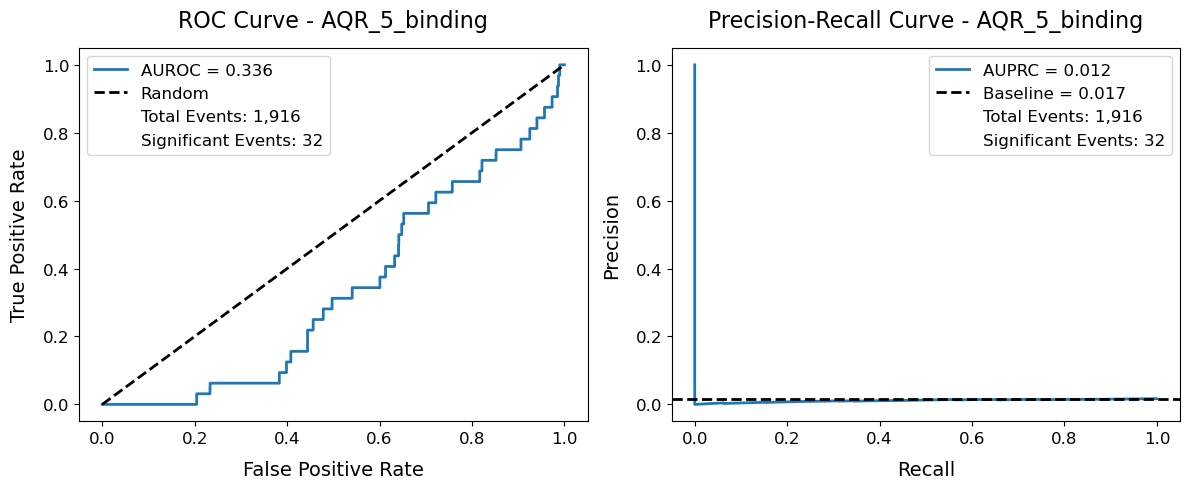

Plotting BCLAF1_1_binding...


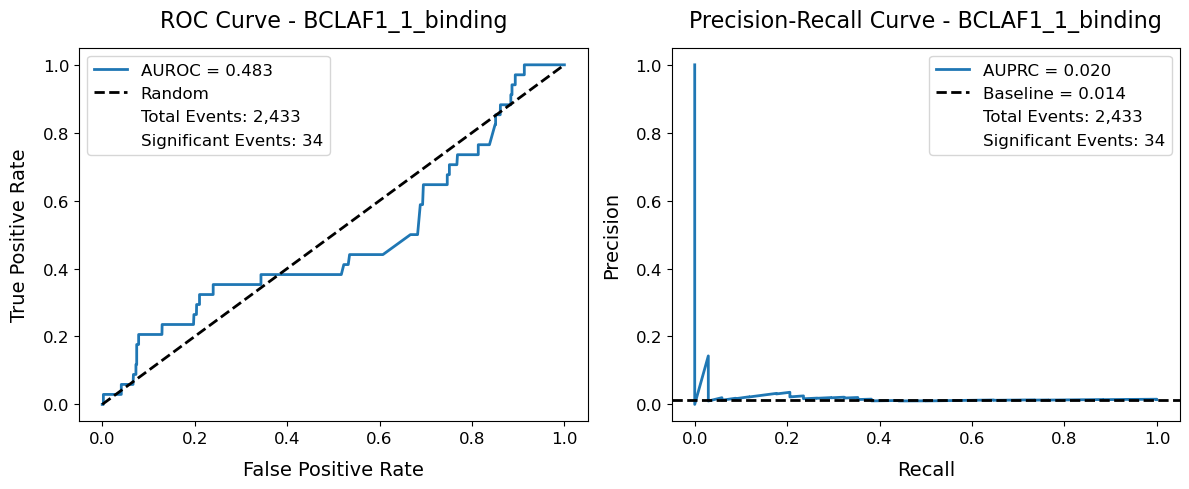

Plotting BCLAF1_2_binding...


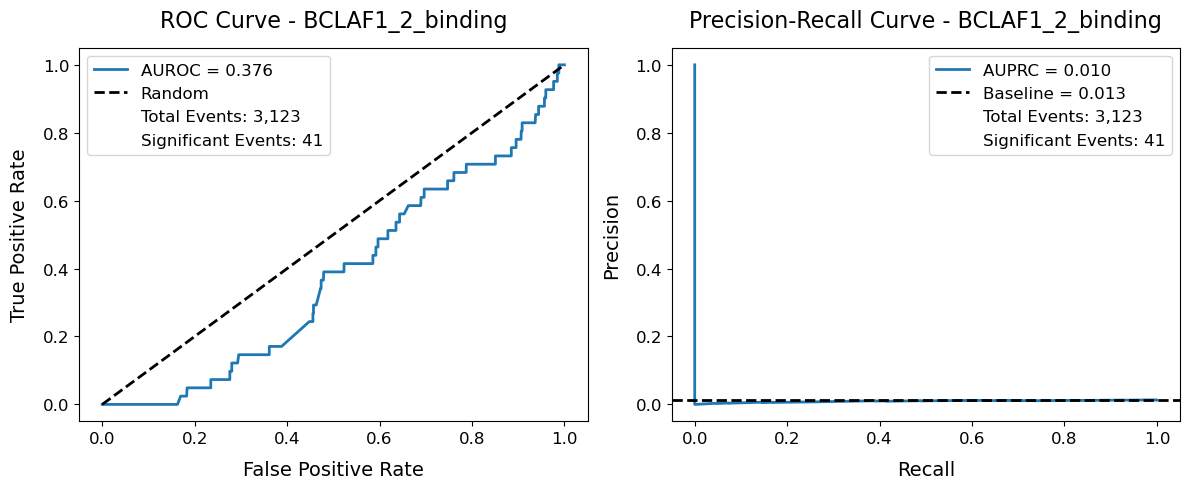

Plotting BCLAF1_5_binding...


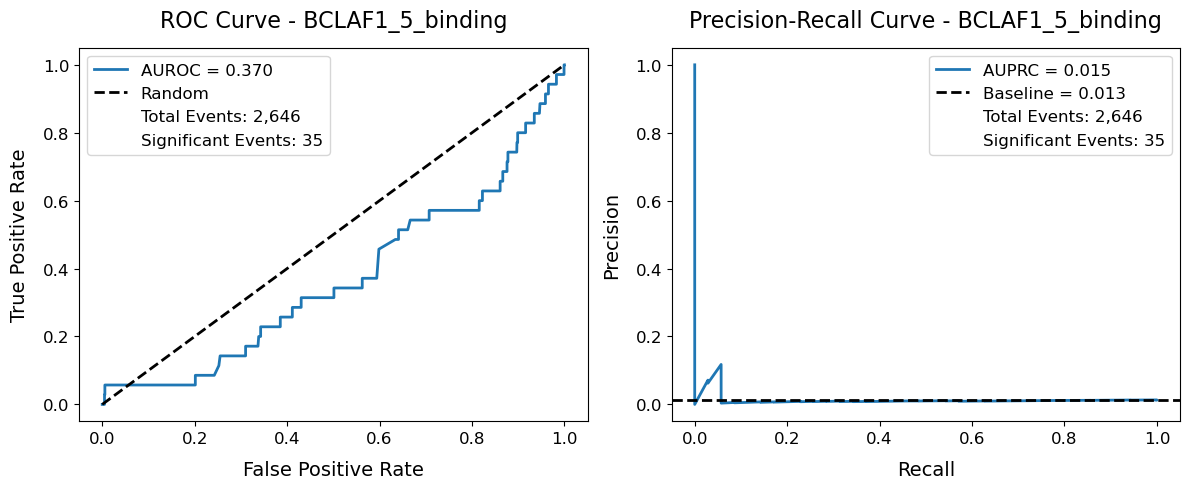

Plotting BCLAF1_6_binding...


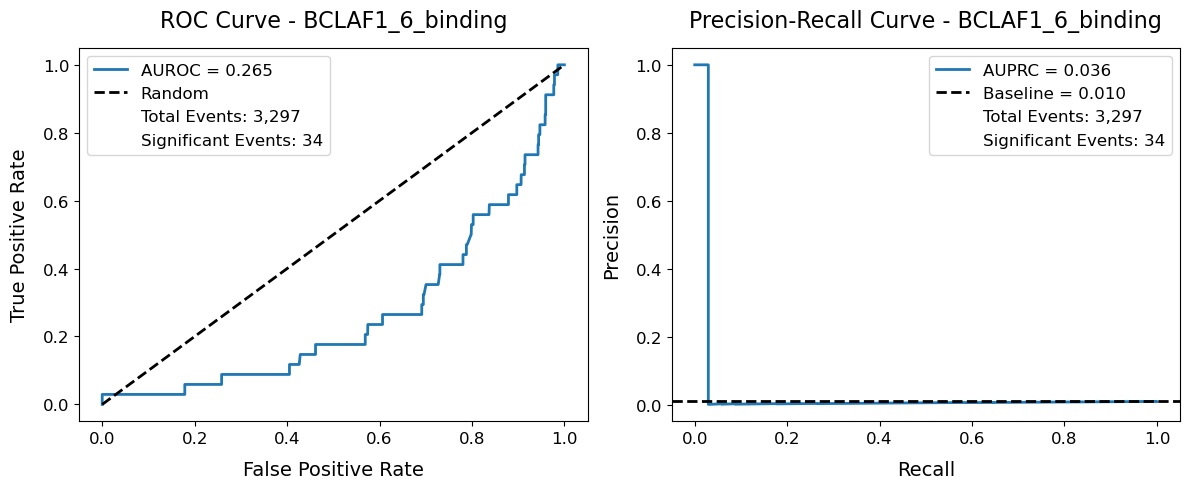

Plotting DDX3X_2_binding...


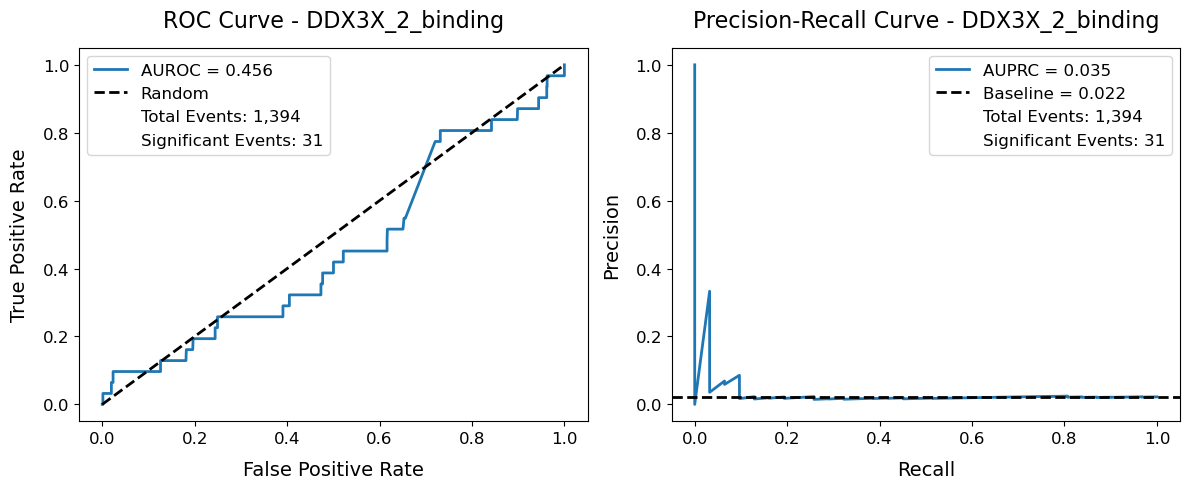

Plotting EFTUD2_2_binding...


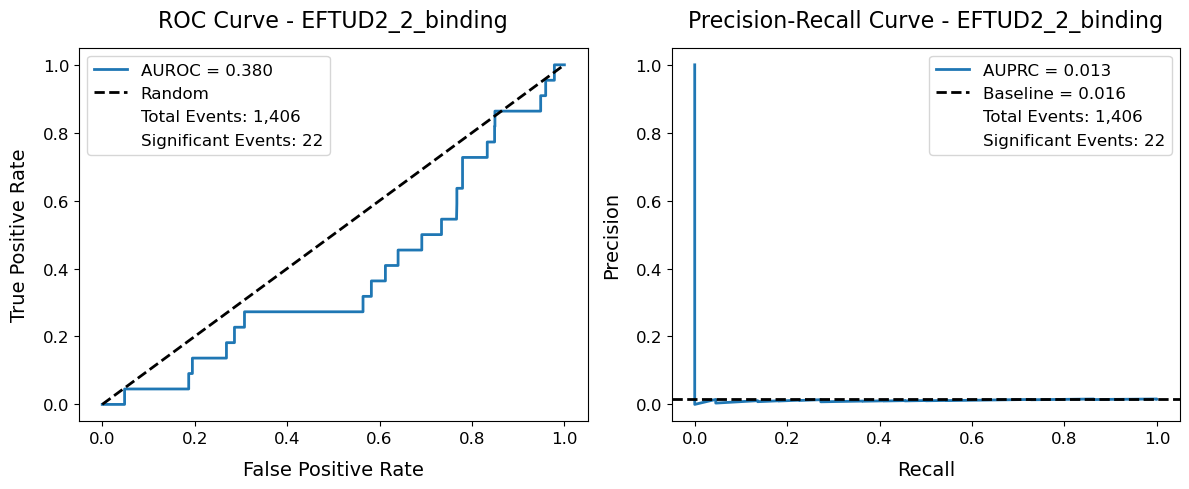

Plotting NCBP2_2_binding...


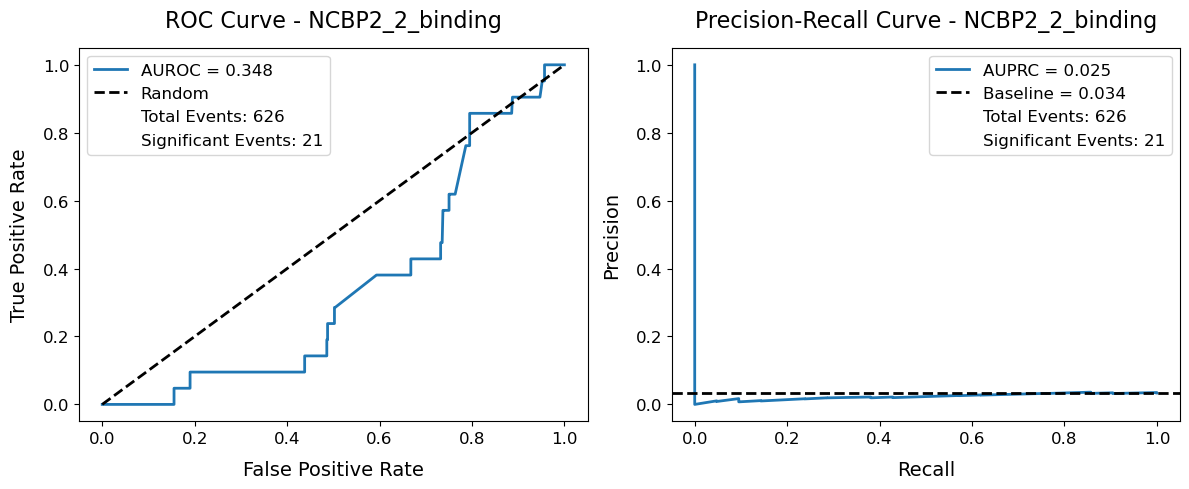

Plotting PRPF8_2_binding...


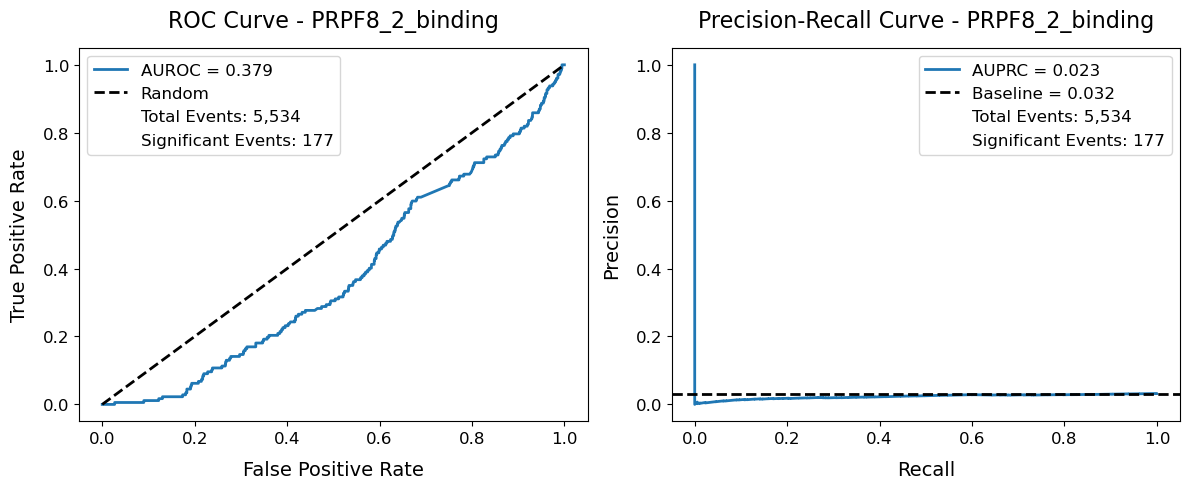

Plotting PRPF8_4_binding...


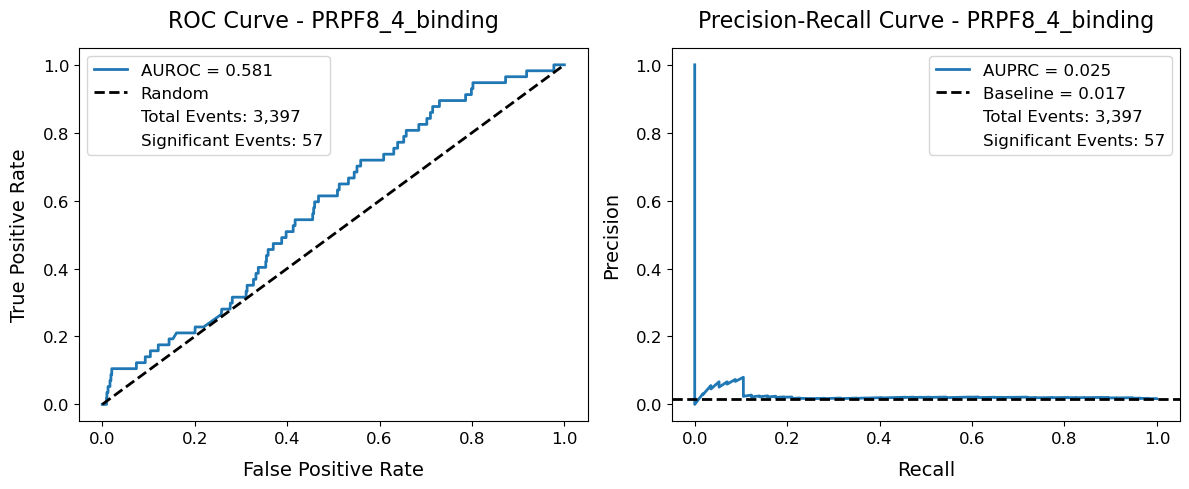

Plotting PRPF8_6_binding...


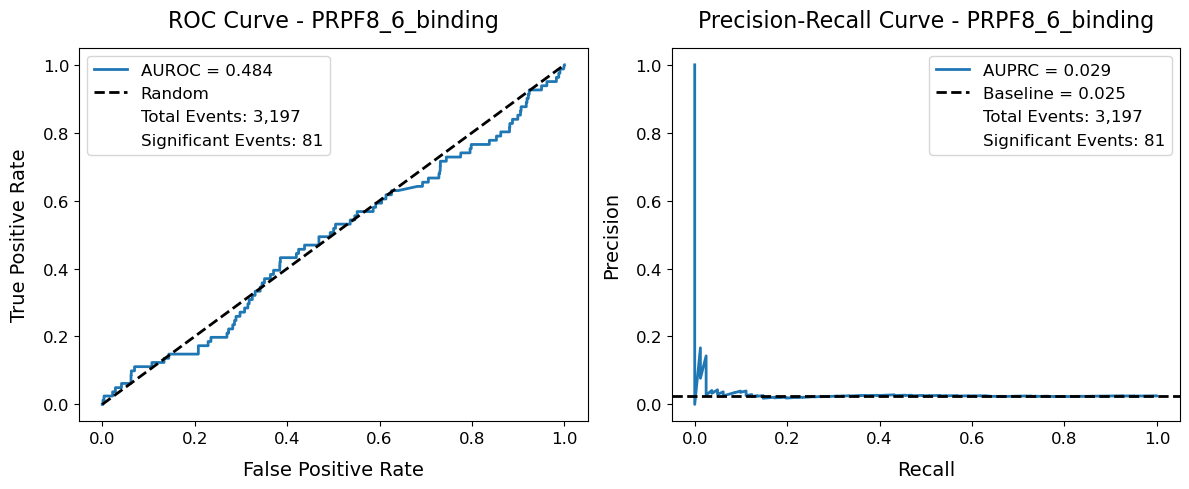

Plotting QKI_4_binding...


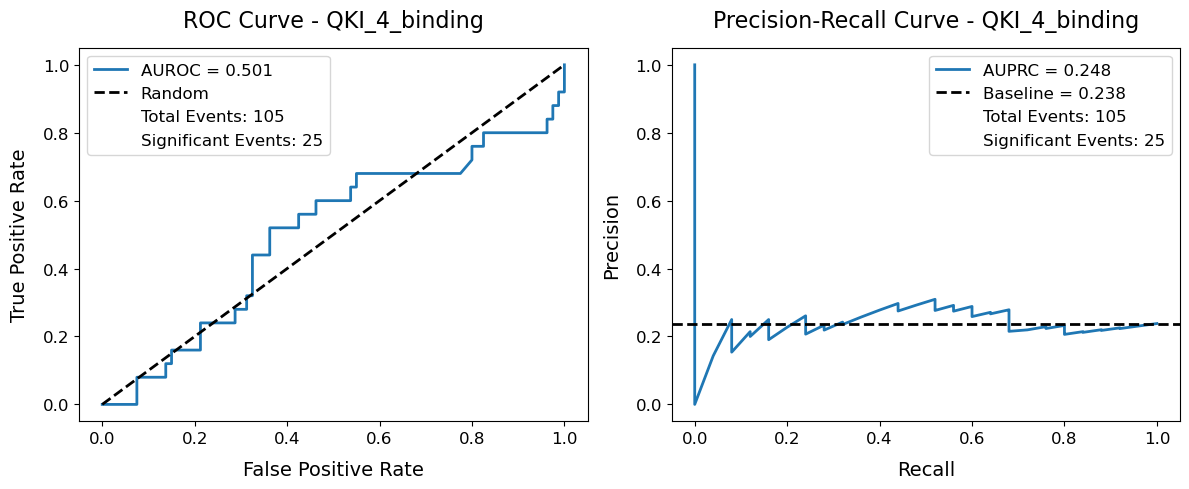

Plotting RBFOX2_4_binding...


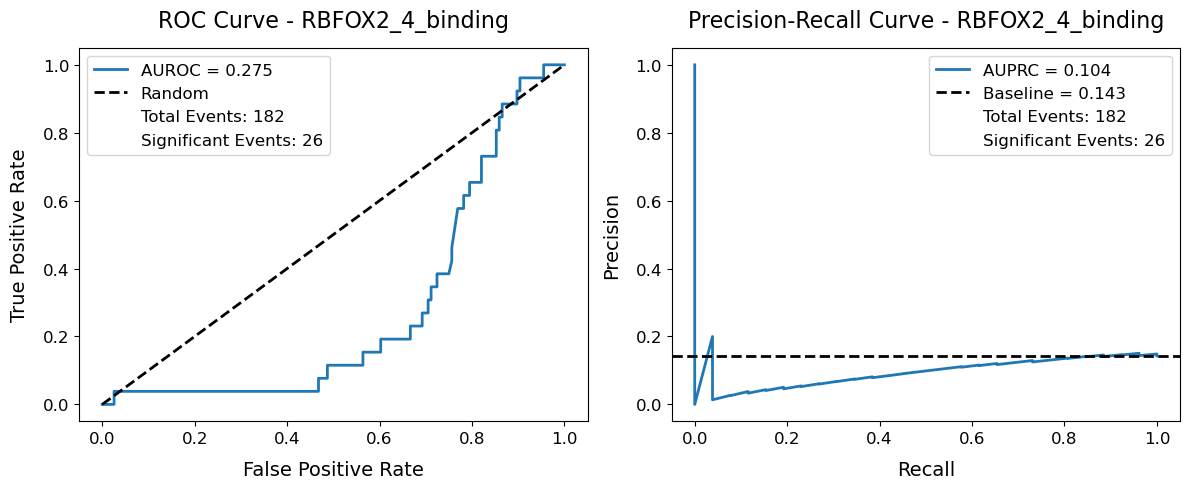

Plotting RBM22_2_binding...


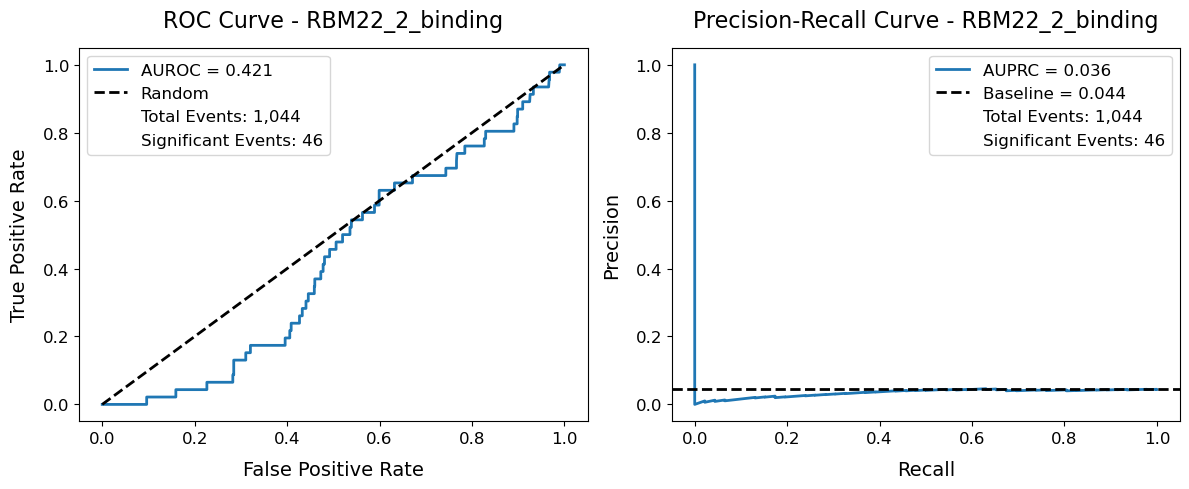

Plotting SF3A3_1_binding...


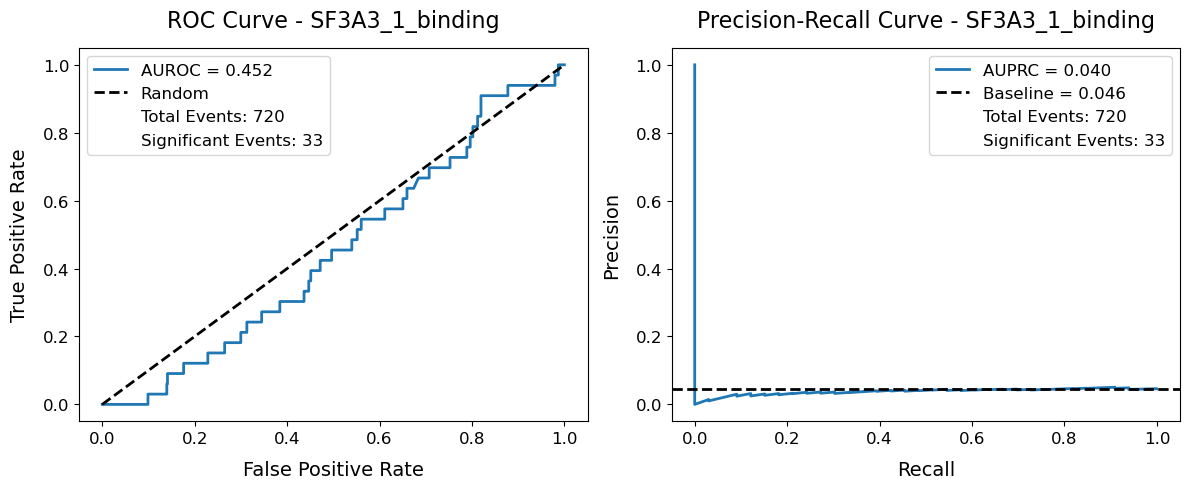

Plotting SF3A3_3_binding...


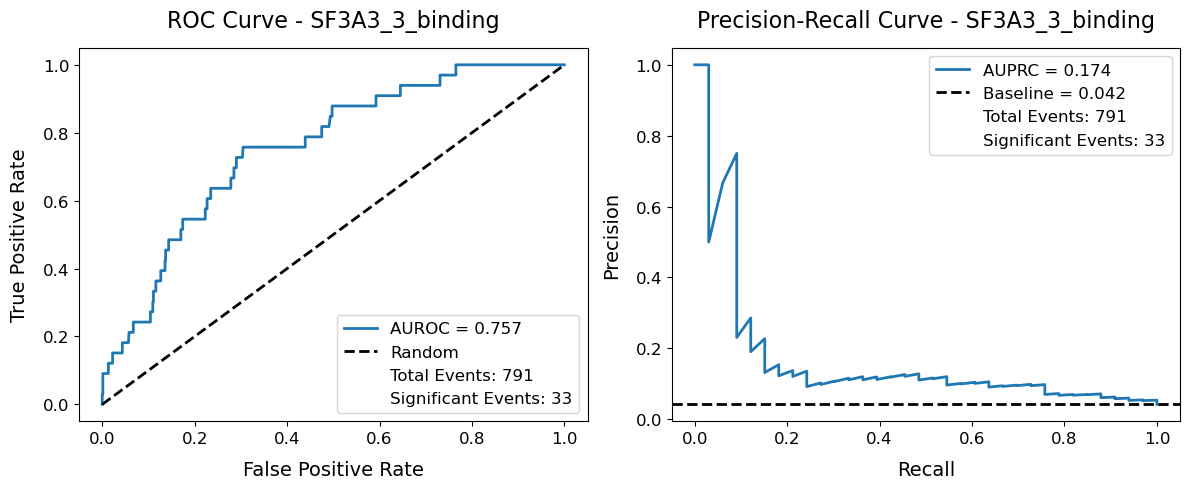

Plotting SF3A3_5_binding...


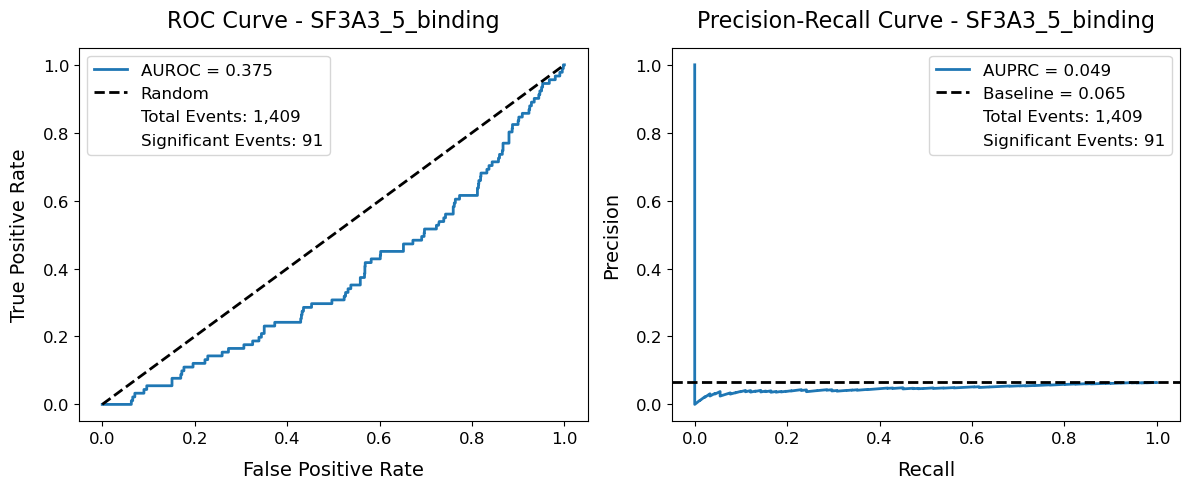

Plotting SF3B4_1_binding...


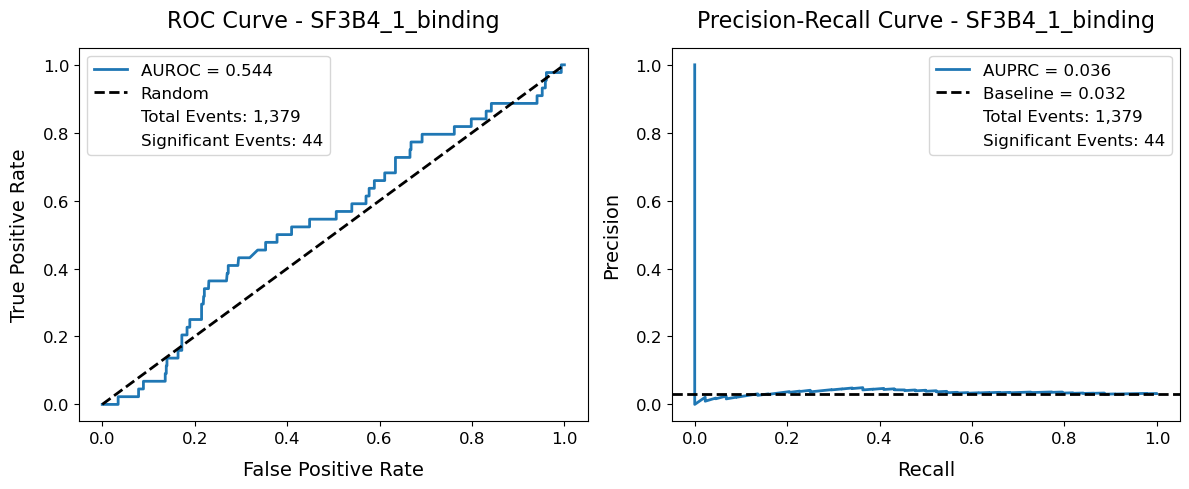

Plotting SF3B4_3_binding...


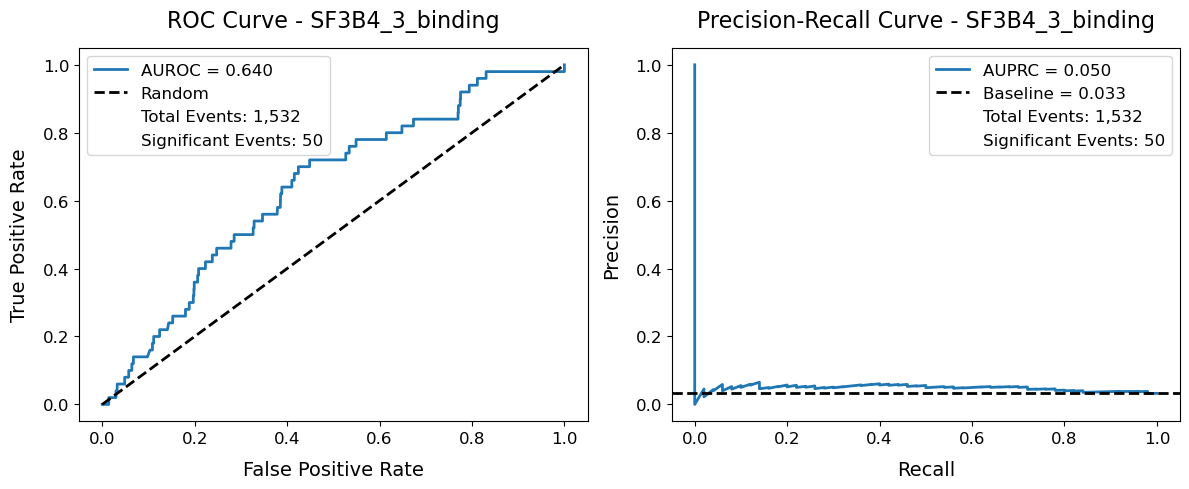

Plotting SF3B4_5_binding...


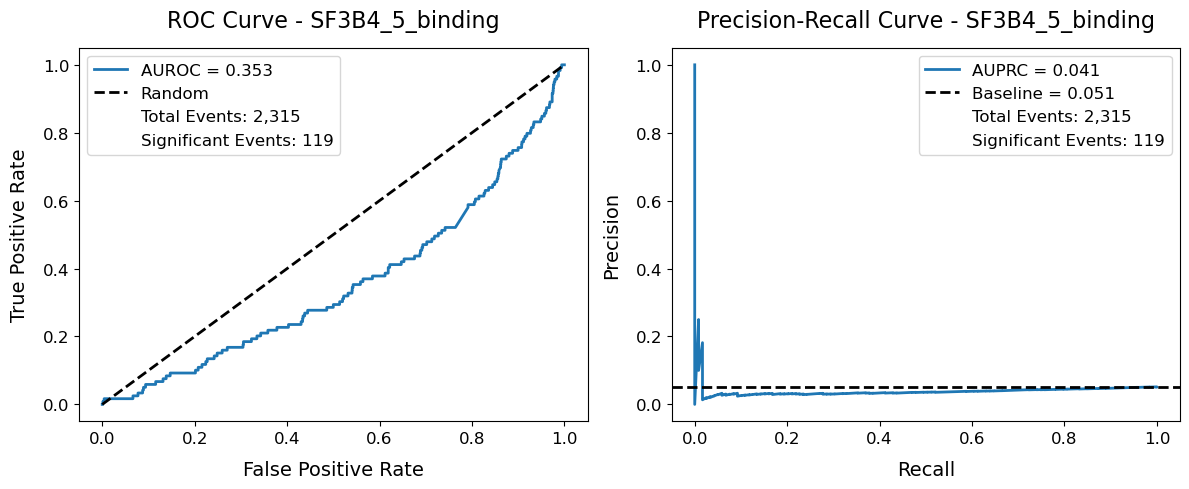

Plotting SRSF1_2_binding...


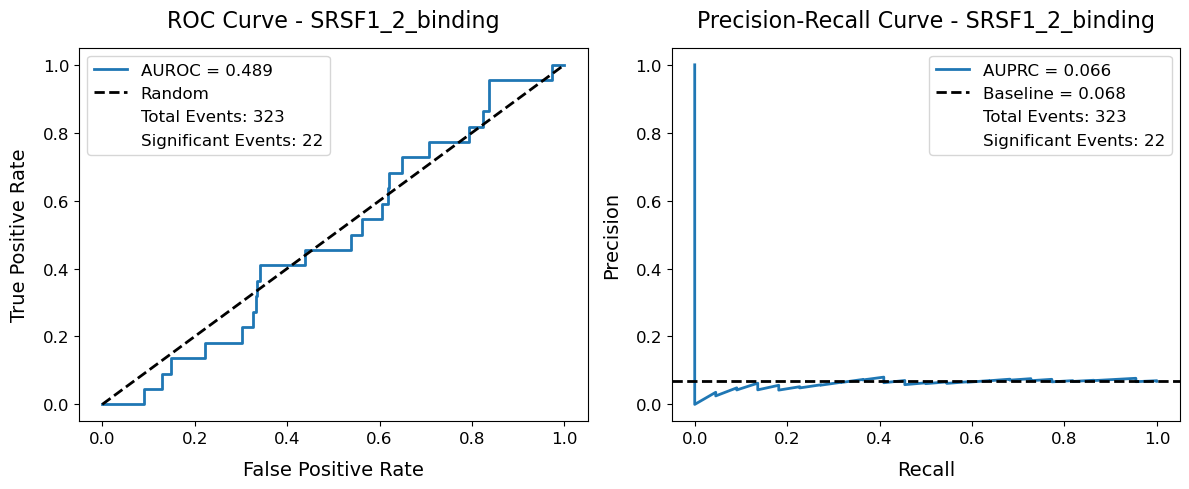

Plotting TIAL1_2_binding...


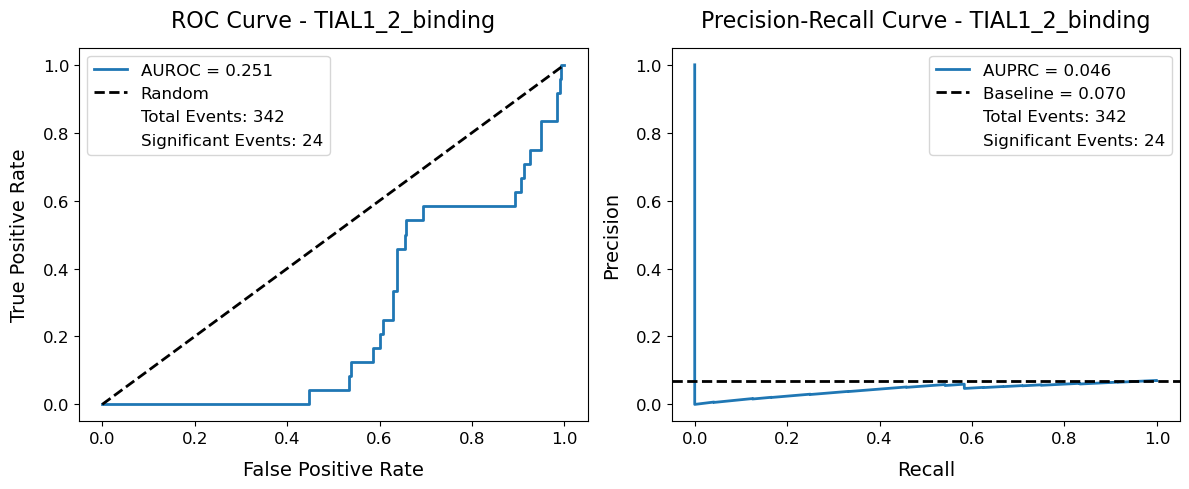

Plotting U2AF1_1_binding...


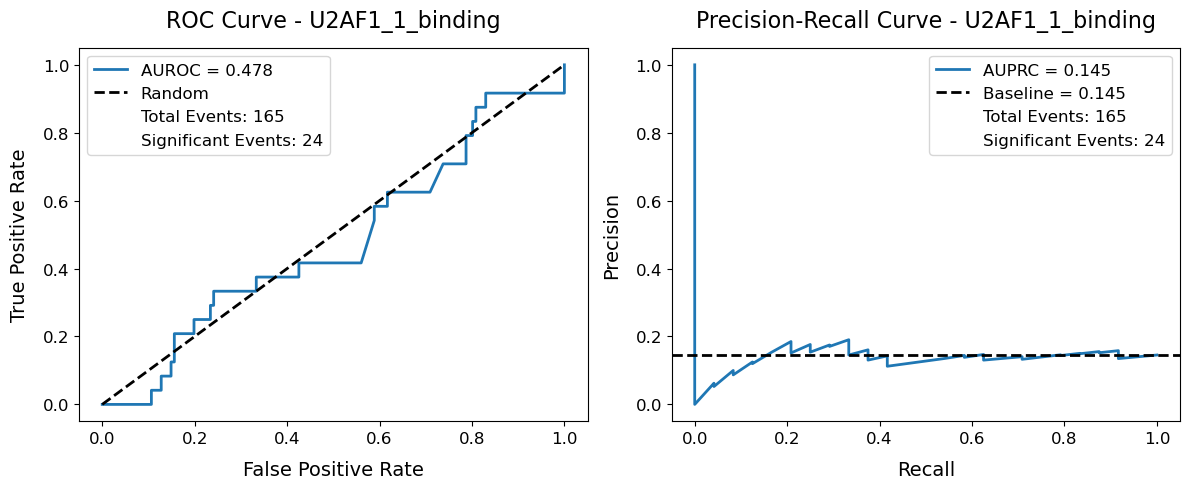

Plotting U2AF1_3_binding...


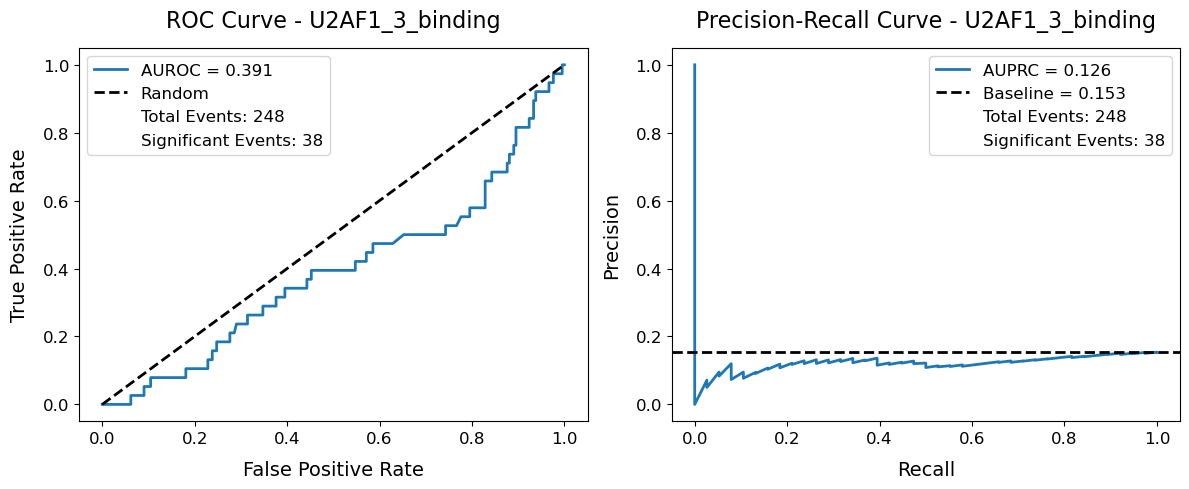

Plotting U2AF1_5_binding...


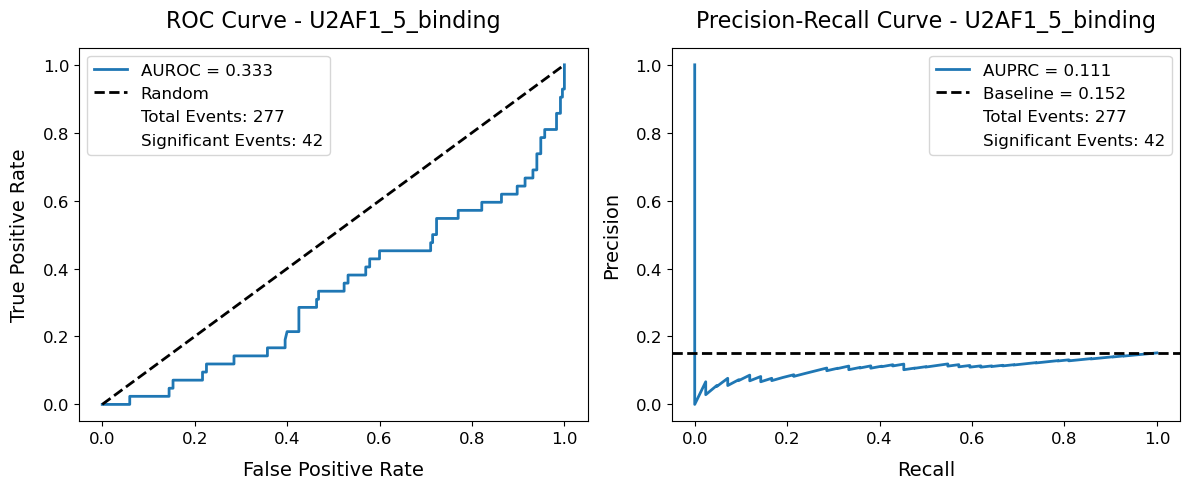

Plotting U2AF2_1_binding...


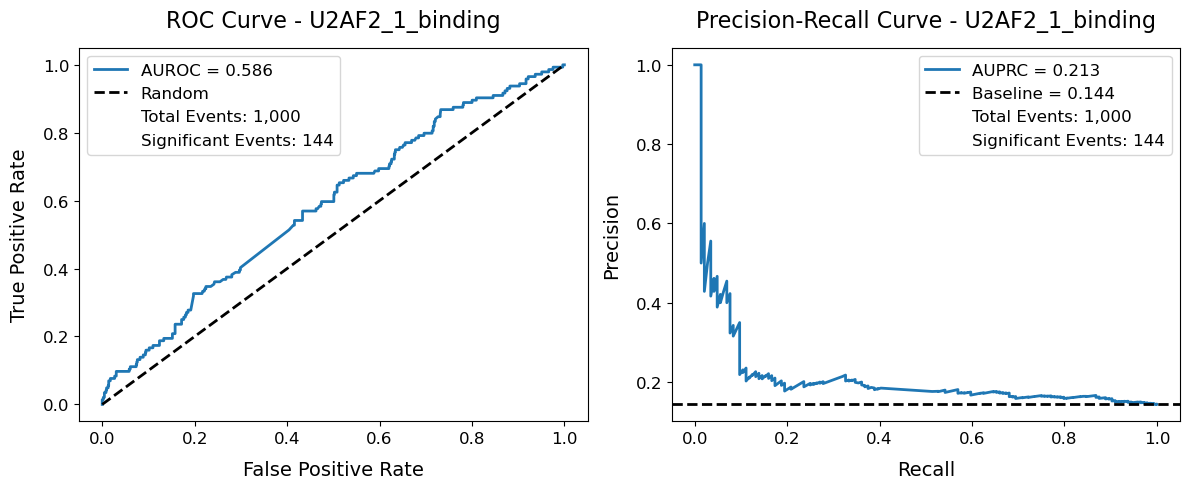

Plotting U2AF2_2_binding...


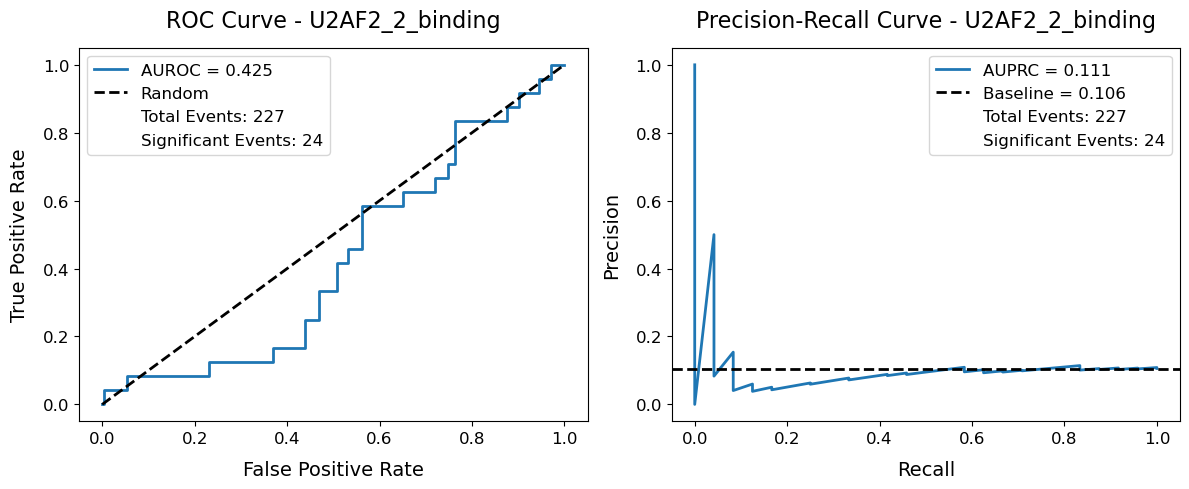

Plotting U2AF2_3_binding...


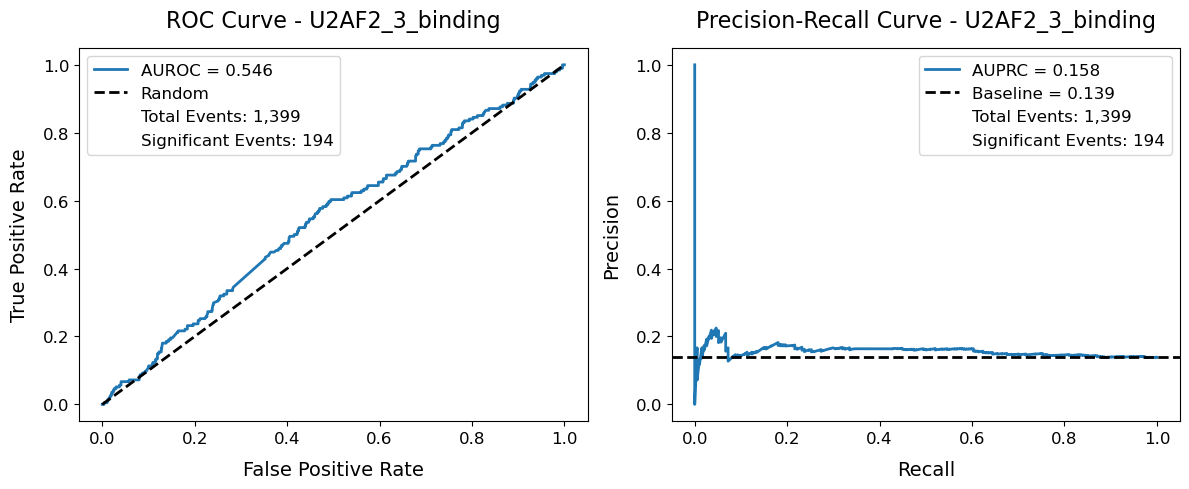

Plotting U2AF2_4_binding...


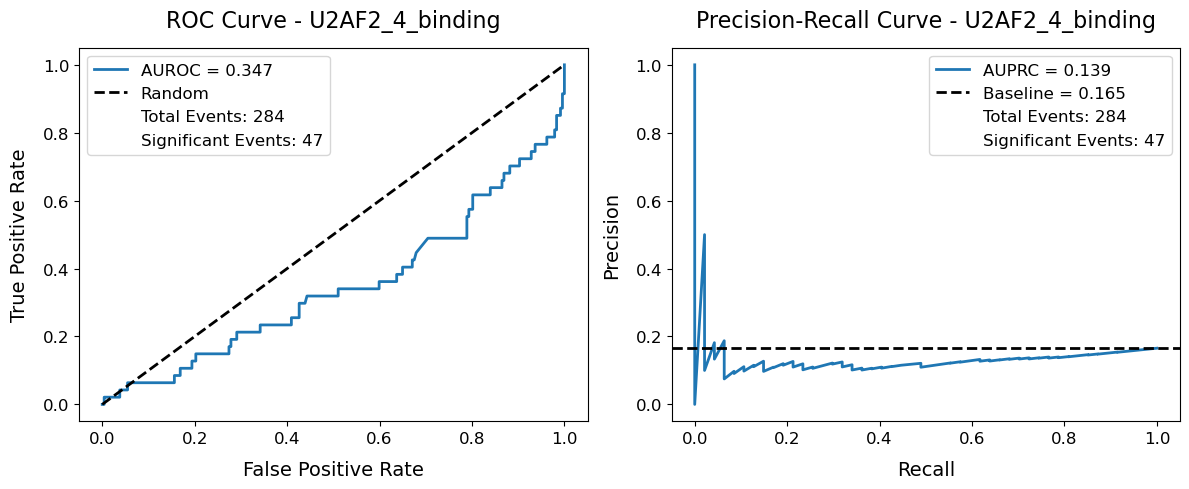

Plotting U2AF2_5_binding...


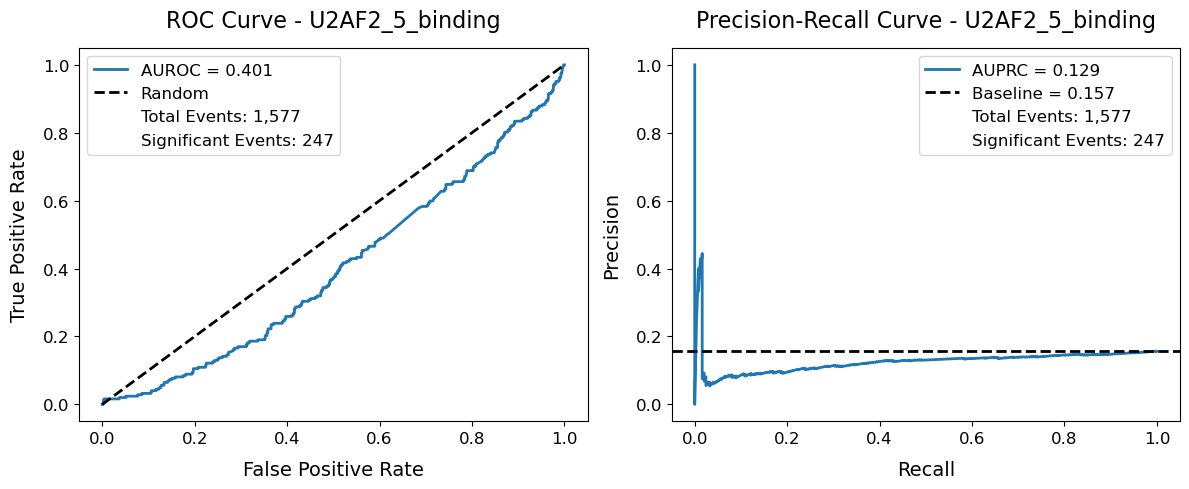


Final Results:
             Feature     AUROC     AUPRC  PRC Baseline  AUPRC - Baseline  \
0    AKAP1_1_binding       NaN       NaN      0.000000               NaN   
1    AKAP1_2_binding       NaN       NaN      0.000000               NaN   
2    AKAP1_3_binding       NaN       NaN      0.000000               NaN   
3    AKAP1_4_binding       NaN       NaN      0.000000               NaN   
4    AKAP1_5_binding  0.585714  0.033333      0.027778          0.005556   
..               ...       ...       ...           ...               ...   
469   YBX3_2_binding  0.466667  0.024390      0.013158          0.011232   
470   YBX3_3_binding       NaN       NaN      0.000000               NaN   
471   YBX3_4_binding       NaN       NaN      0.000000               NaN   
472   YBX3_5_binding       NaN       NaN      0.000000               NaN   
473   YBX3_6_binding  0.294118  0.016393      0.011628          0.004766   

     Total Events  Num Significant  
0              14                0

In [10]:
HepG2 = get_roc_prc("HepG2")

Plotting AQR_1_binding...


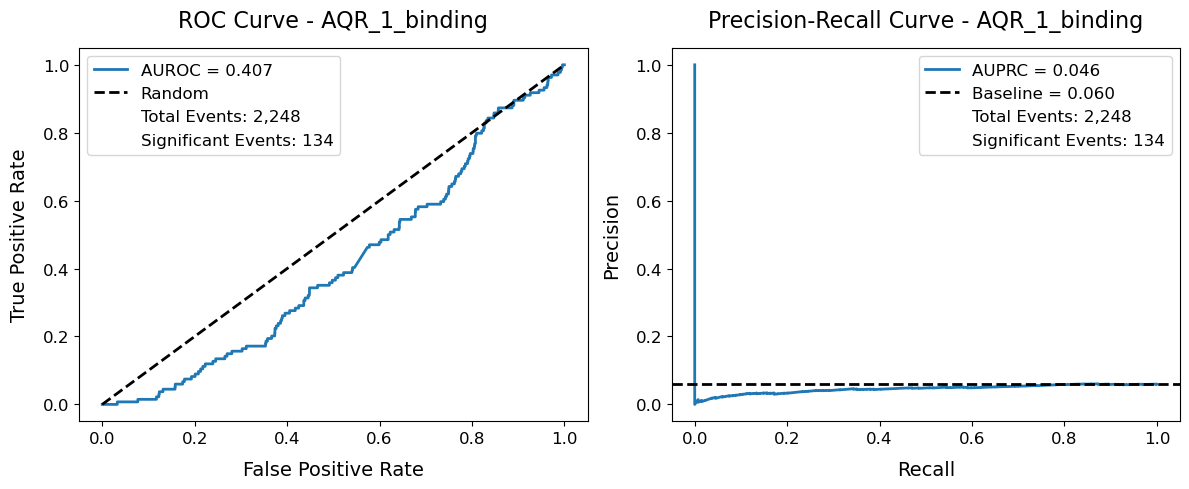

Plotting AQR_2_binding...


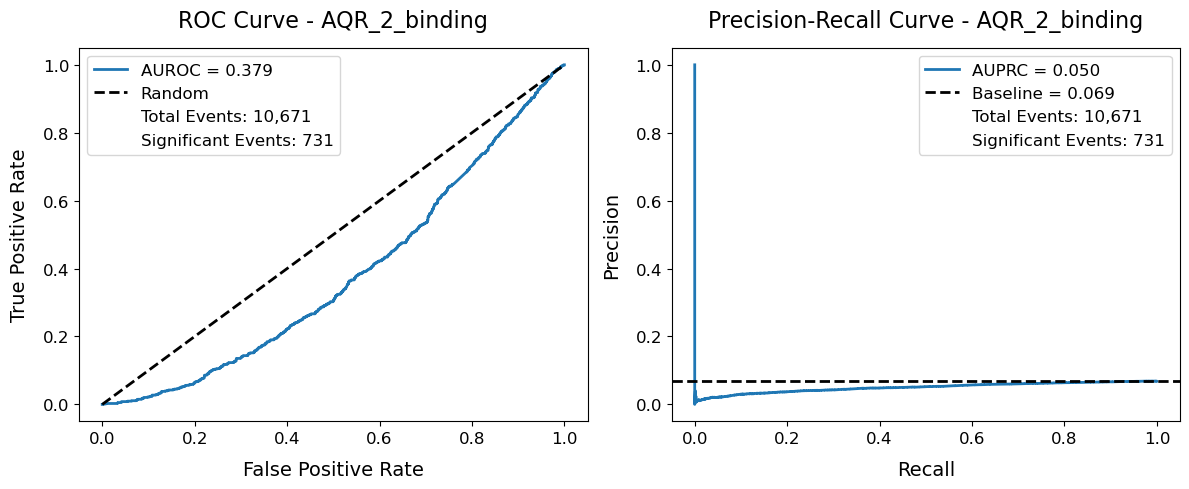

Plotting AQR_3_binding...


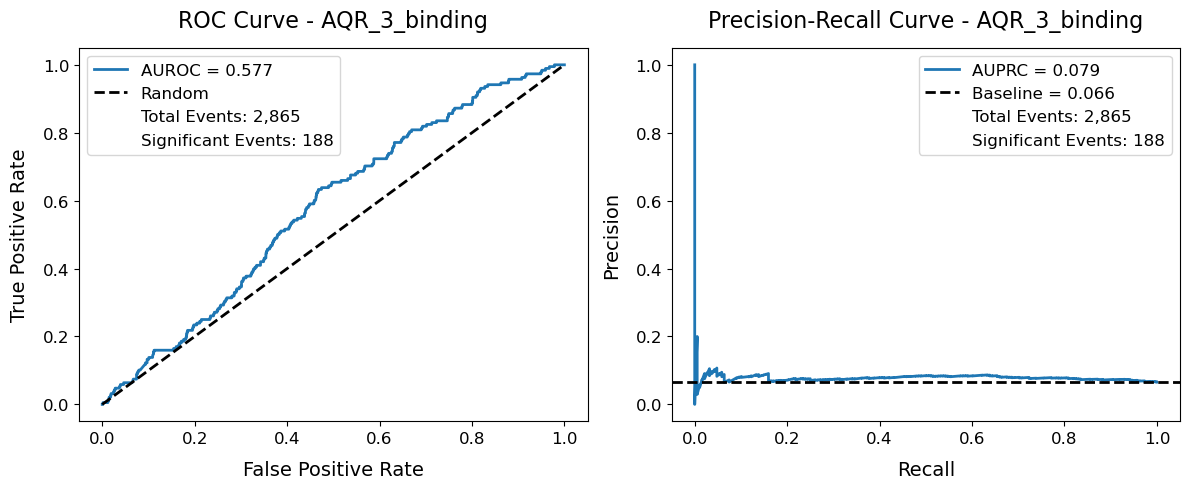

Plotting AQR_4_binding...


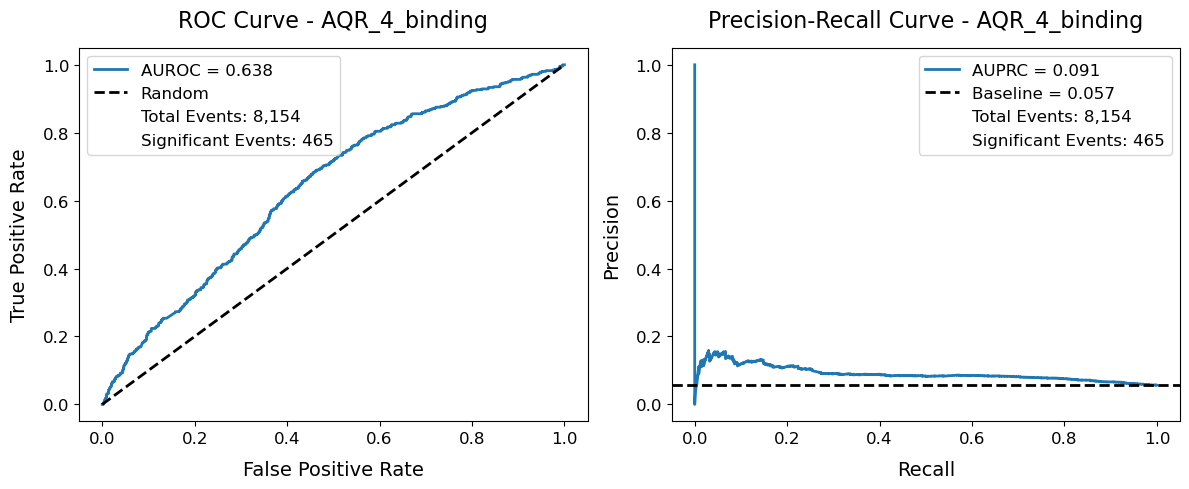

Plotting AQR_5_binding...


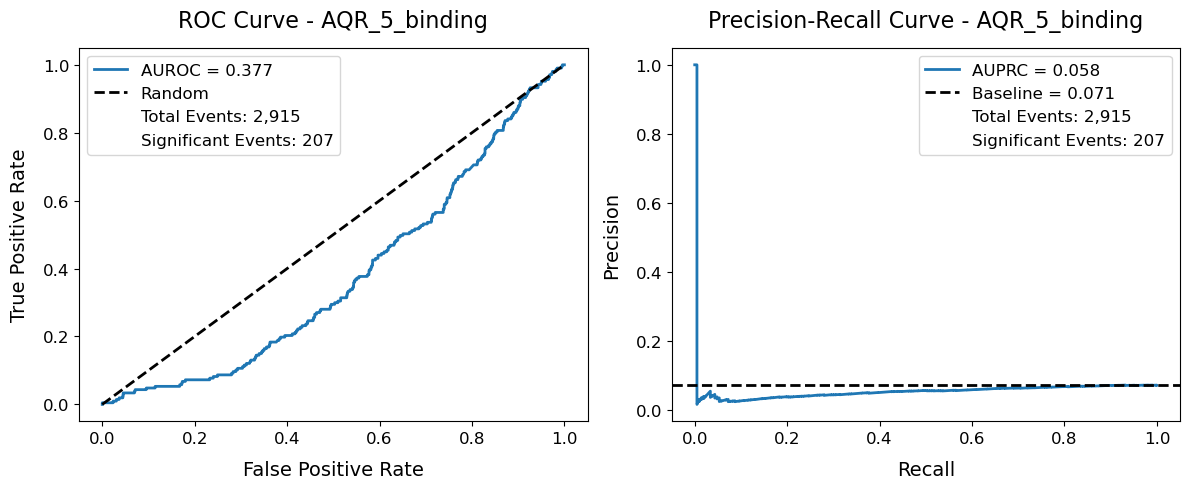

Plotting AQR_6_binding...


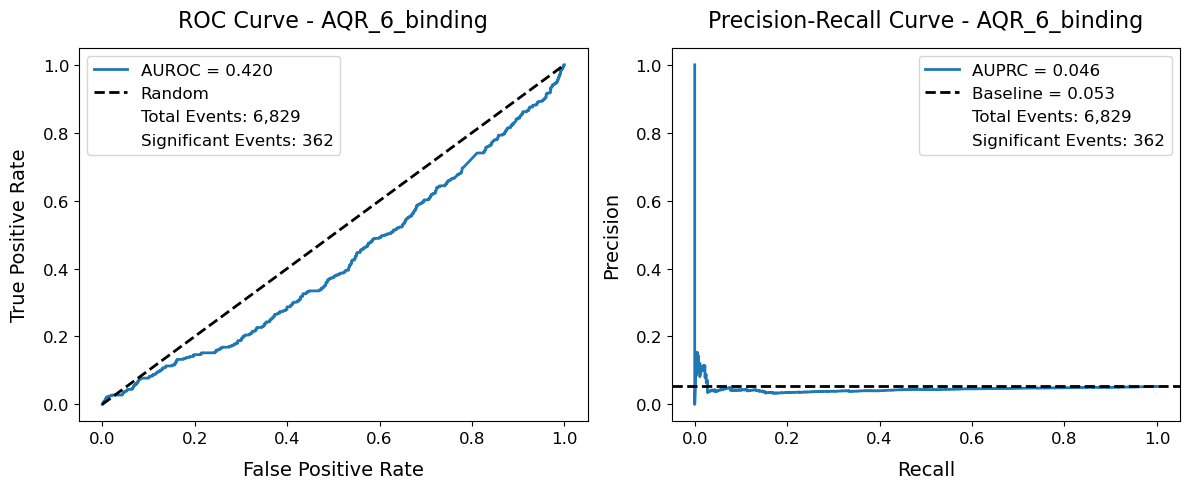

Plotting EFTUD2_2_binding...


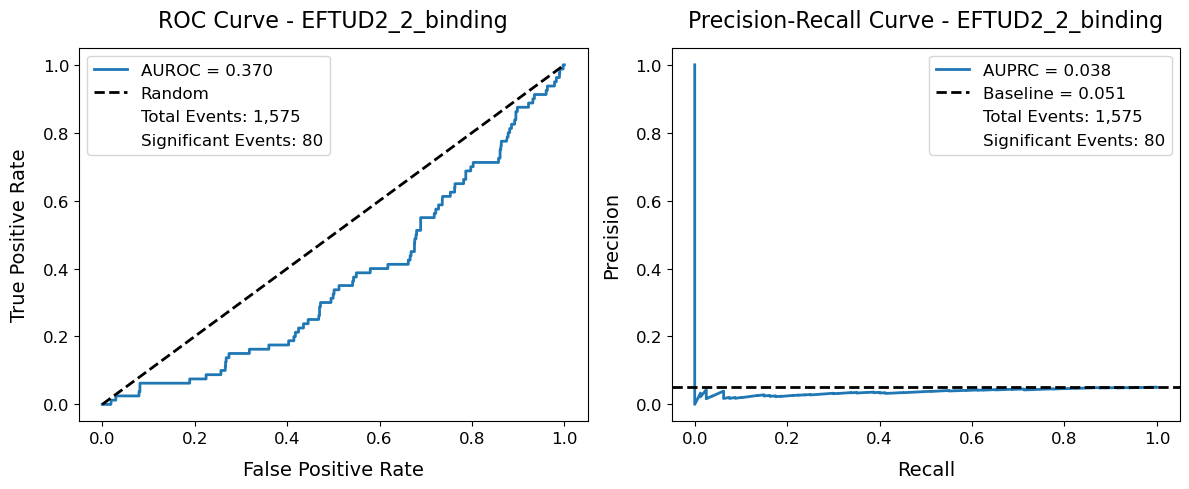

Plotting EFTUD2_3_binding...


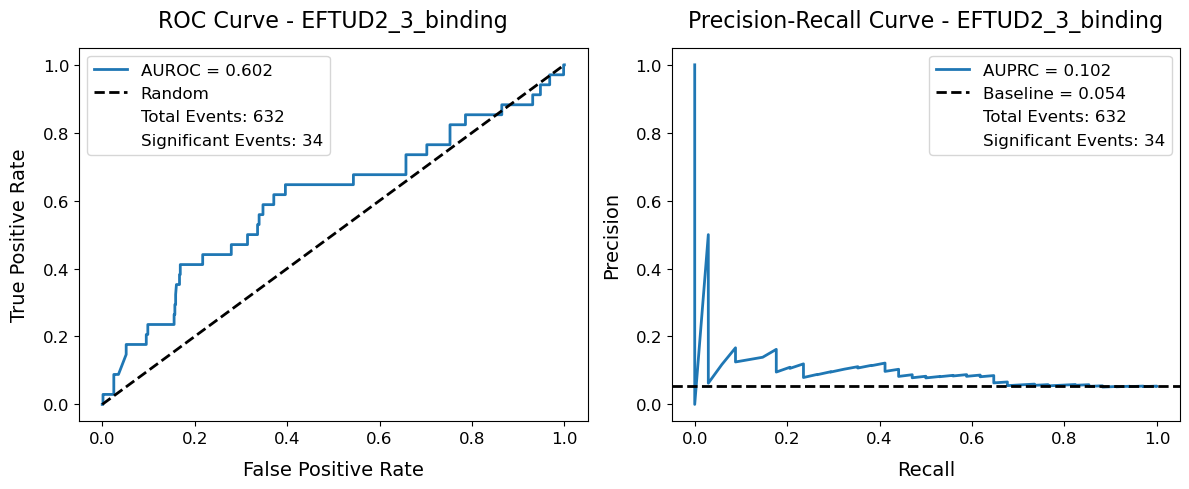

Plotting EFTUD2_4_binding...


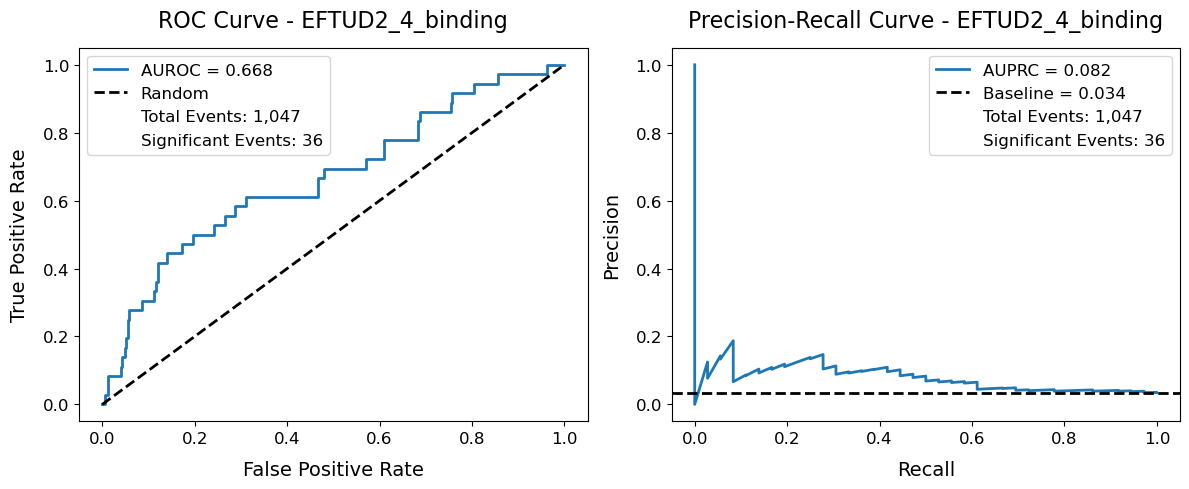

Plotting EFTUD2_5_binding...


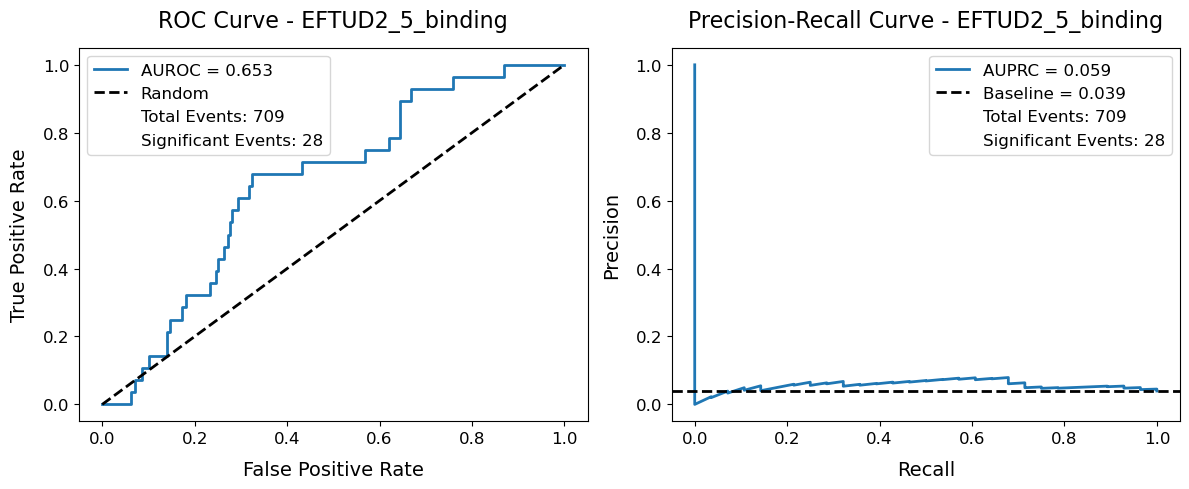

Plotting EFTUD2_6_binding...


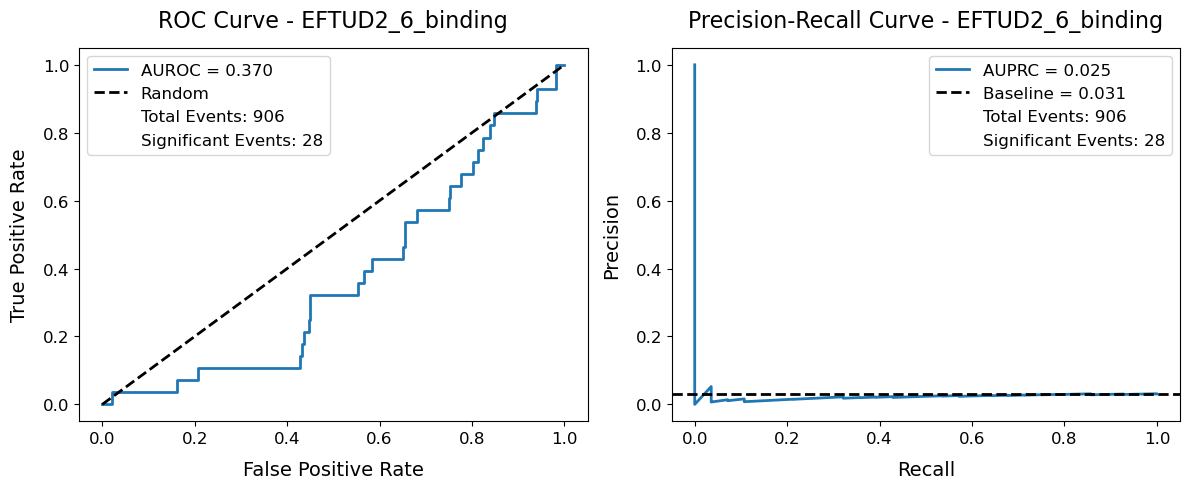

Plotting KHSRP_5_binding...


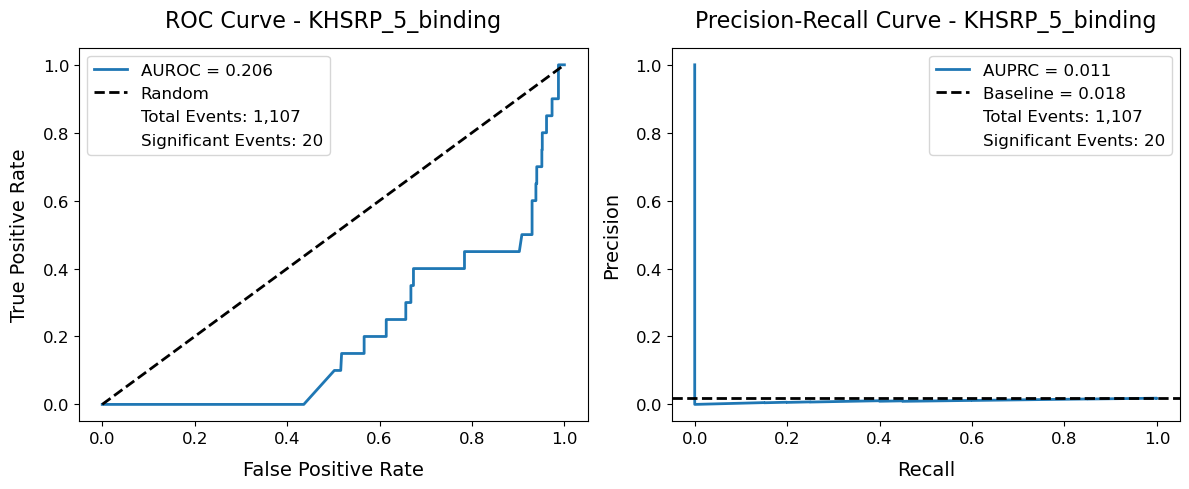

Plotting RBM15_1_binding...


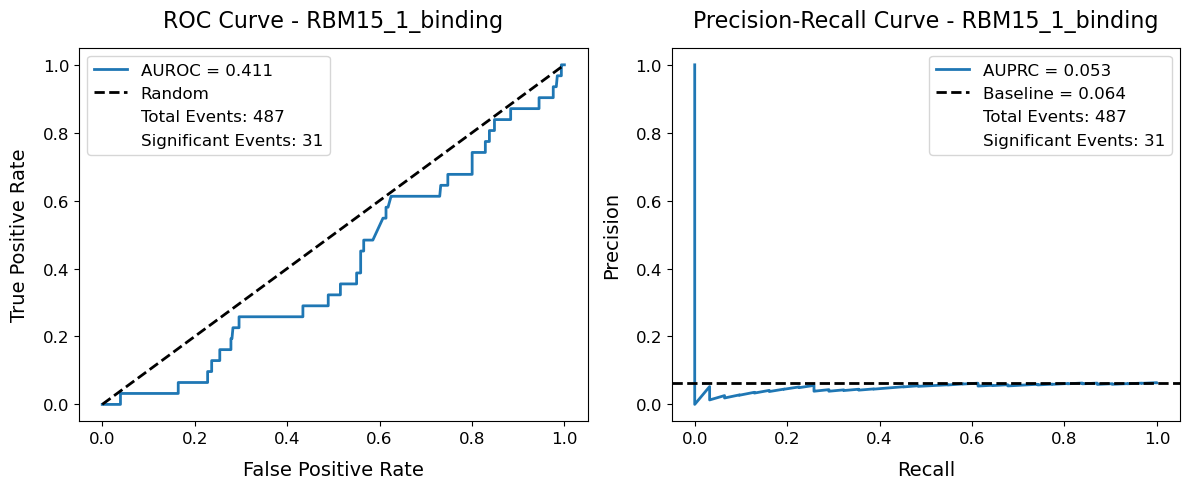

Plotting RBM15_2_binding...


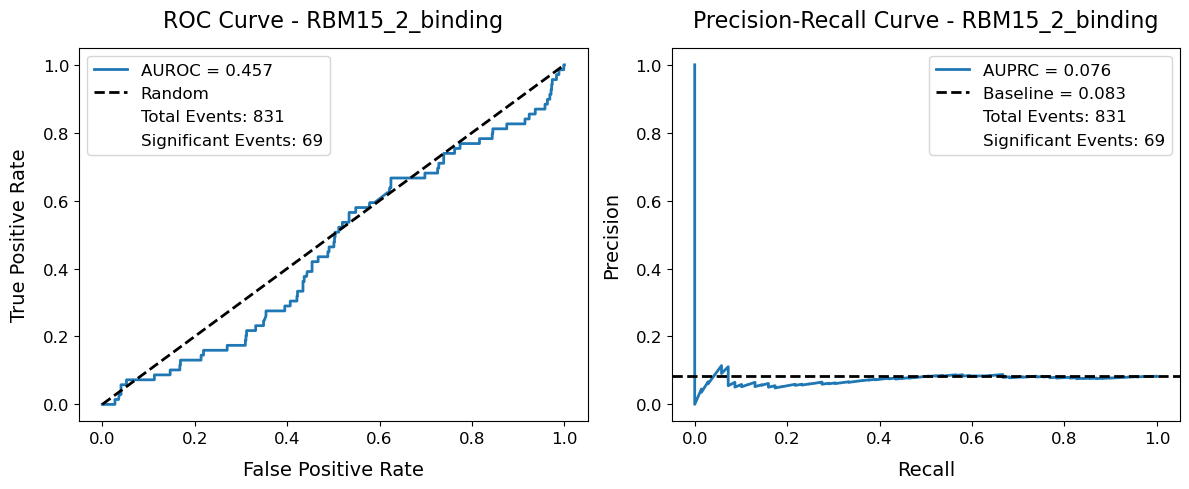

Plotting RBM15_5_binding...


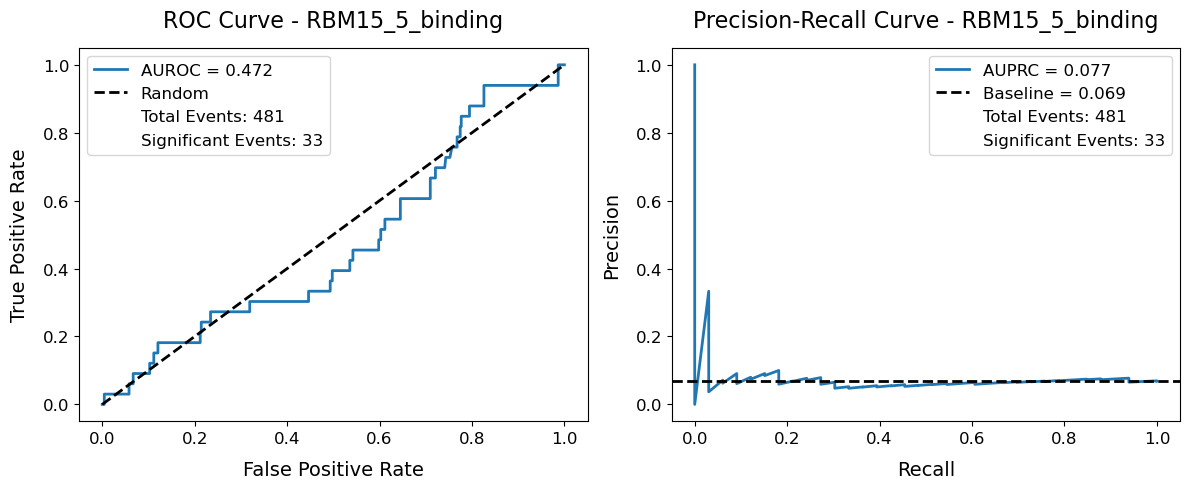

Plotting RBM15_6_binding...


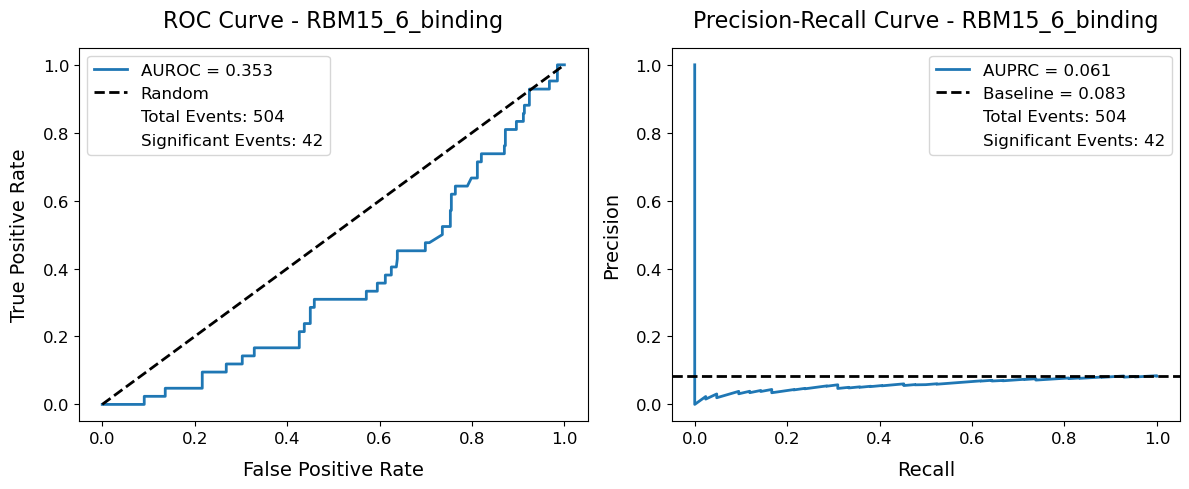

Plotting SF3B4_1_binding...


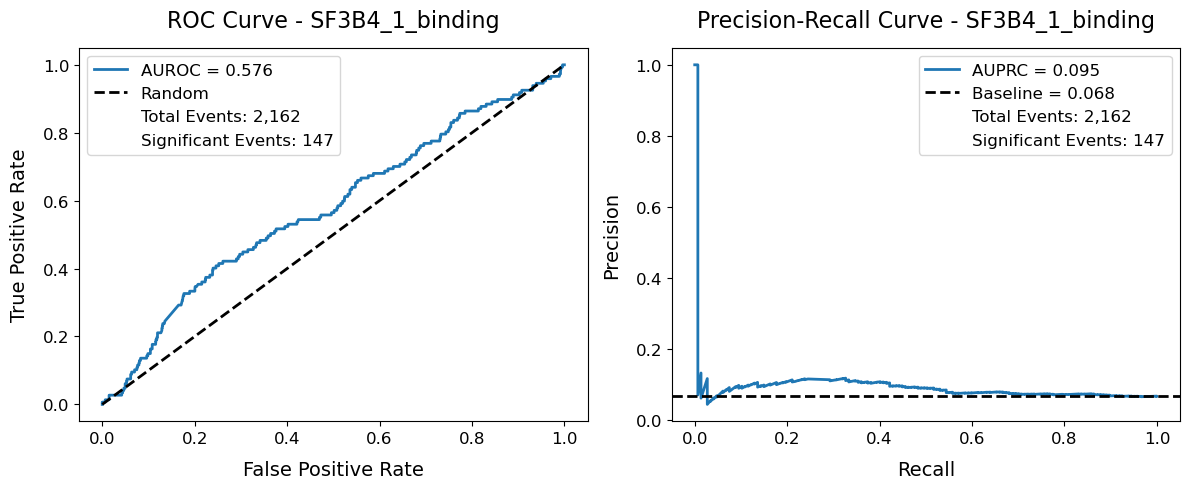

Plotting SF3B4_2_binding...


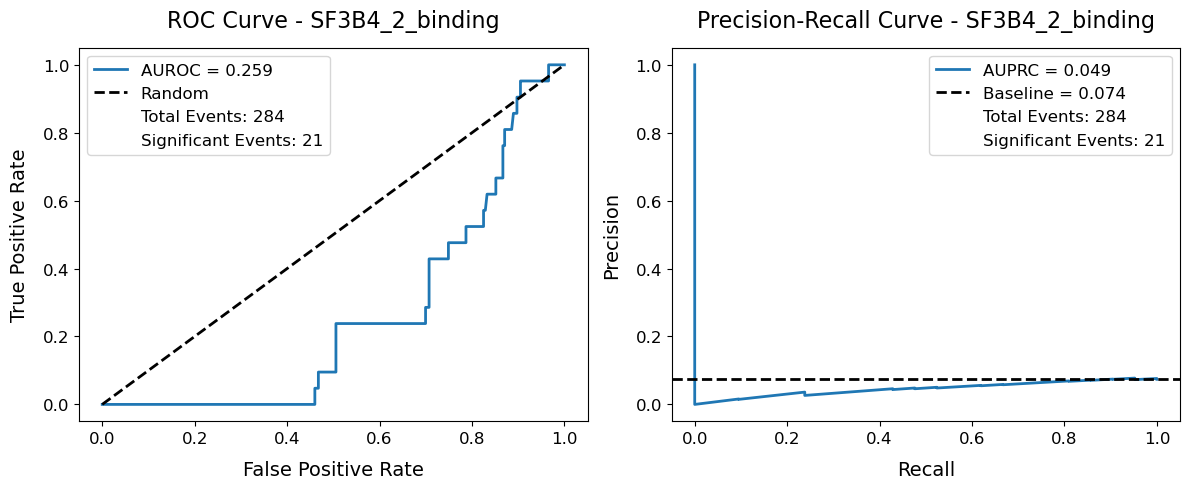

Plotting SF3B4_3_binding...


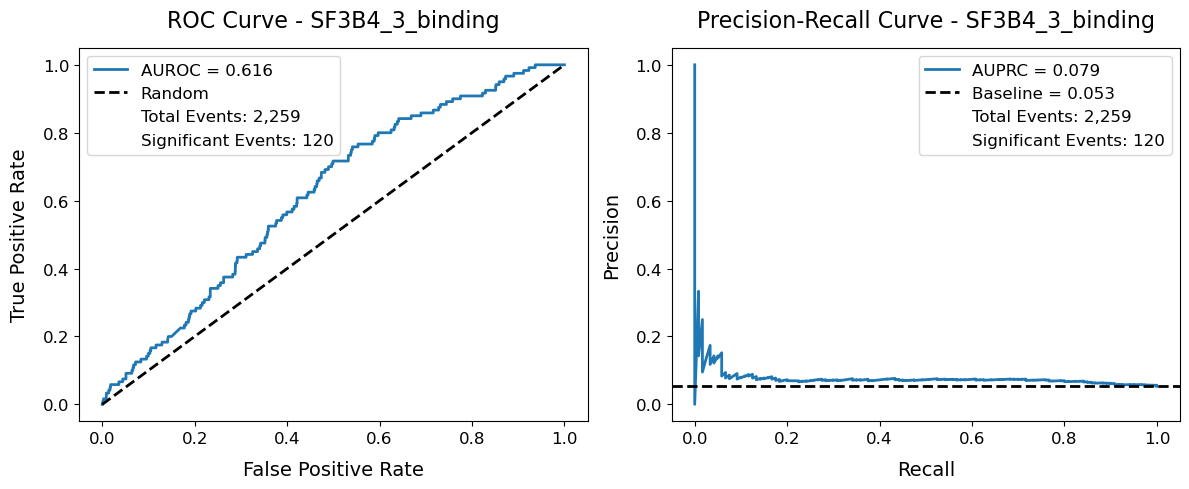

Plotting SF3B4_4_binding...


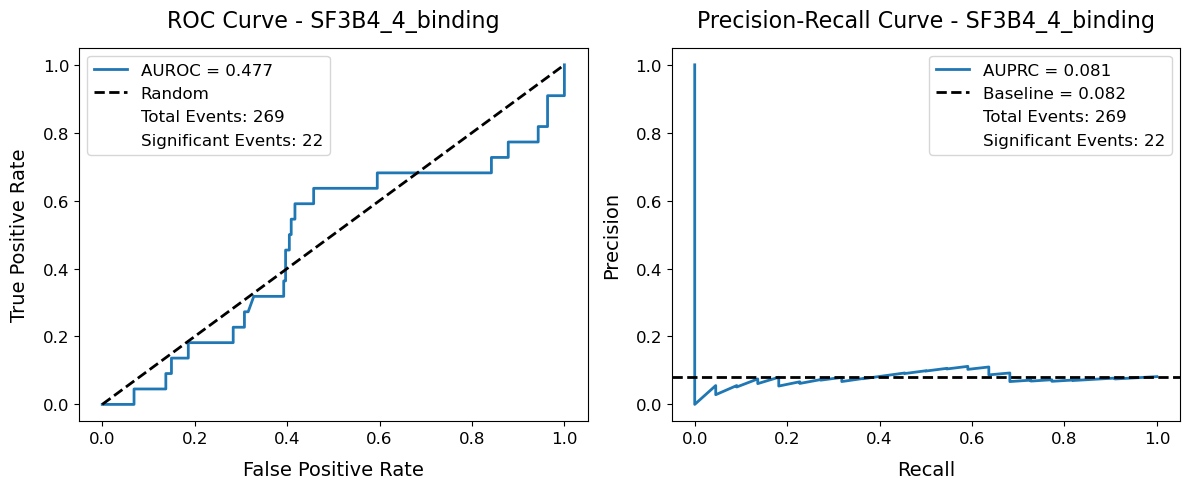

Plotting SF3B4_5_binding...


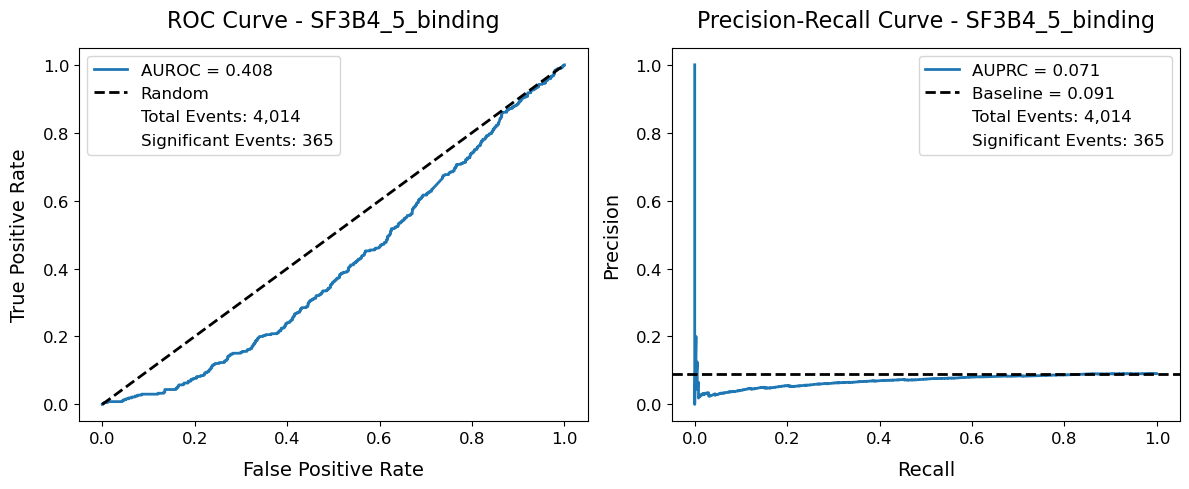

Plotting SF3B4_6_binding...


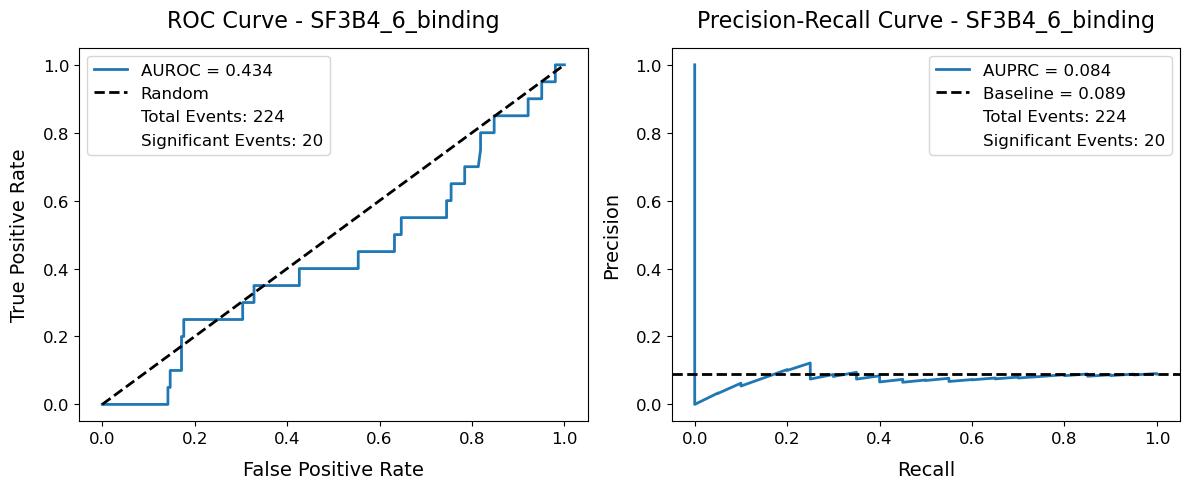

Plotting SRSF1_2_binding...


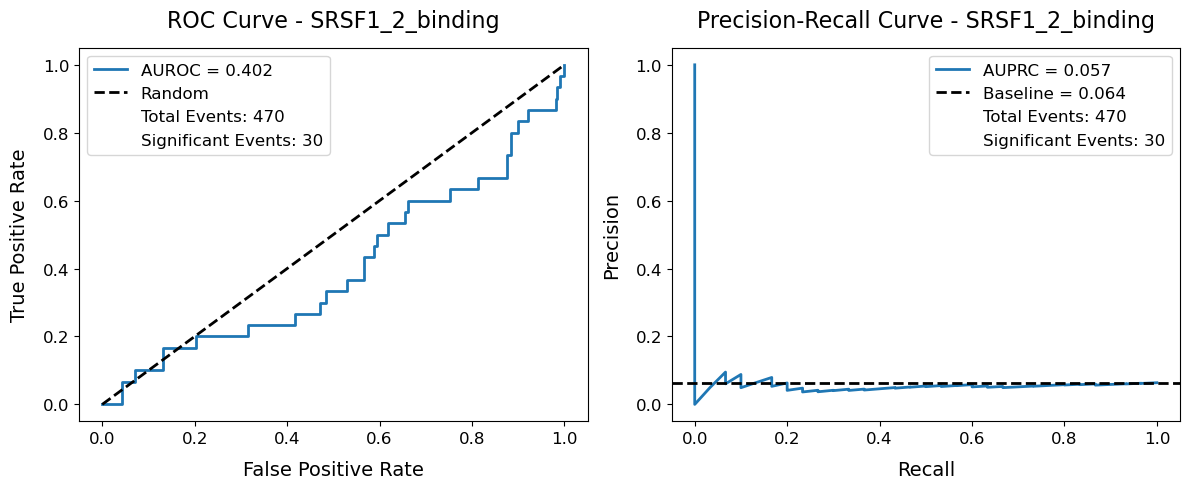

Plotting SRSF1_4_binding...


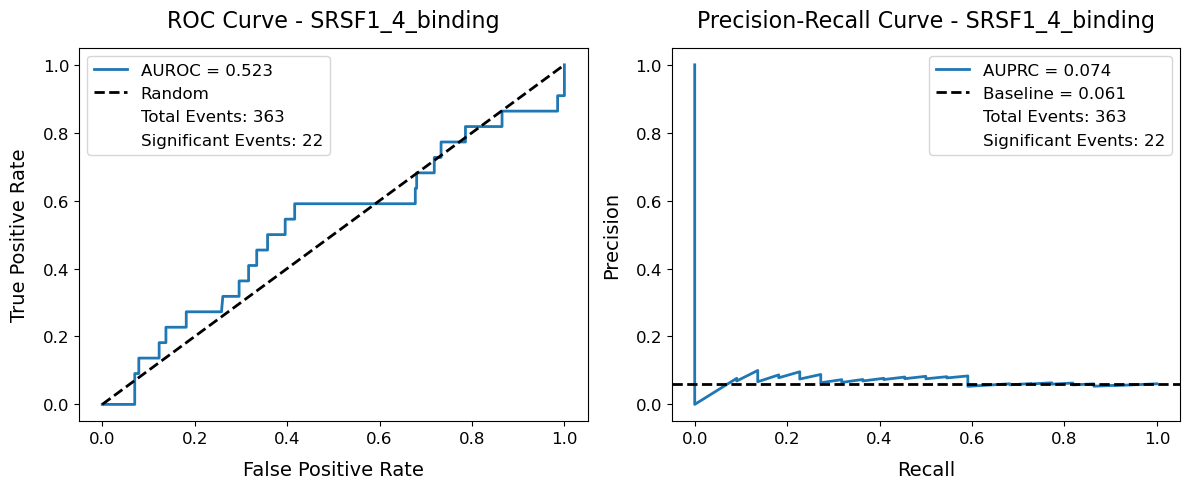

Plotting SRSF1_5_binding...


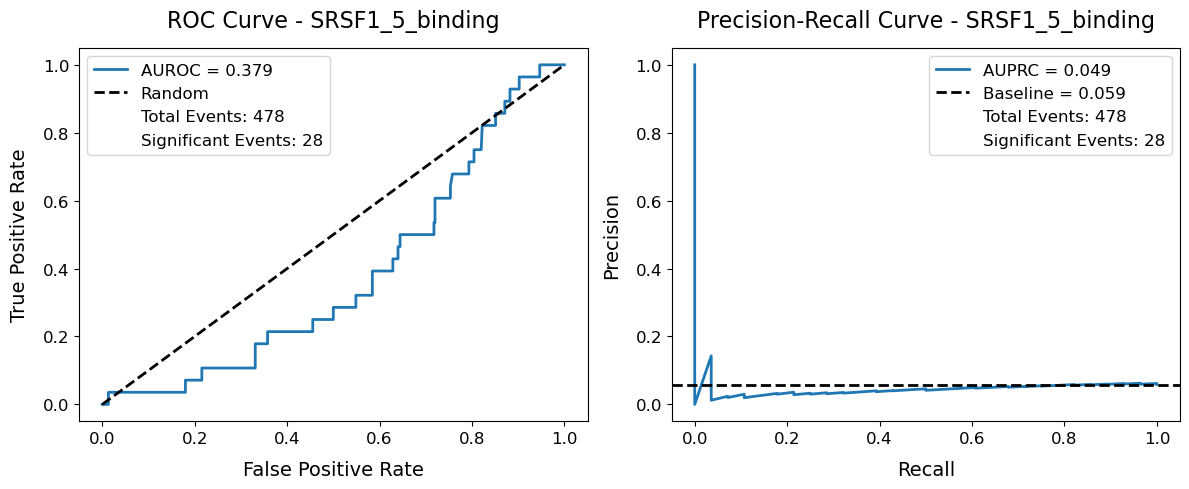

Plotting SRSF1_6_binding...


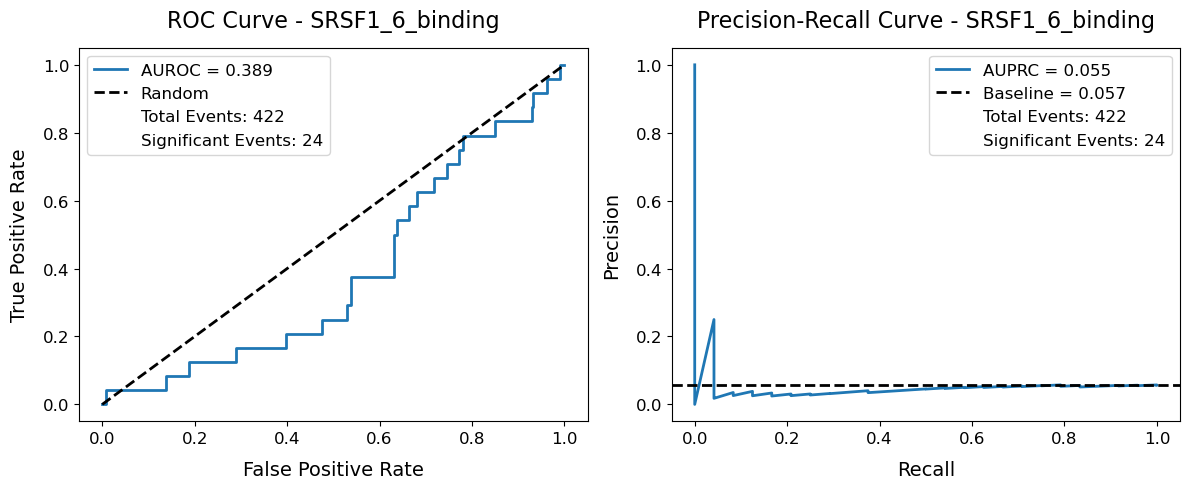

Plotting U2AF1_1_binding...


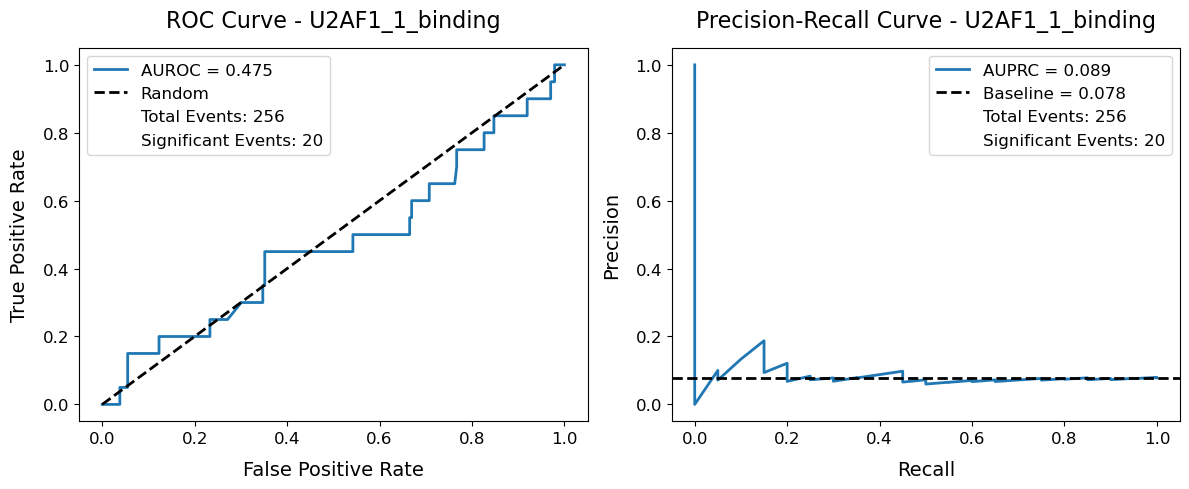

Plotting U2AF1_3_binding...


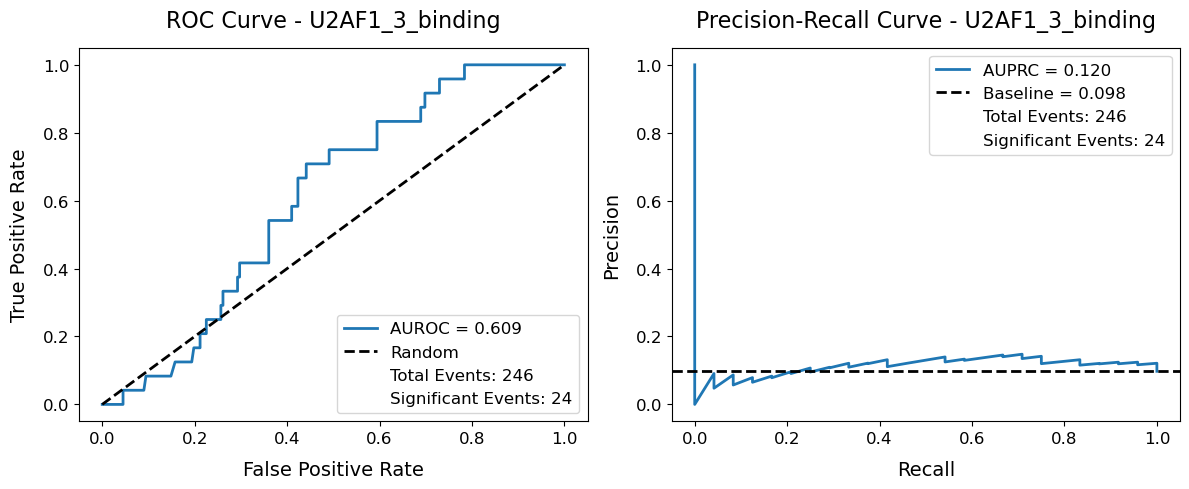

Plotting U2AF1_5_binding...


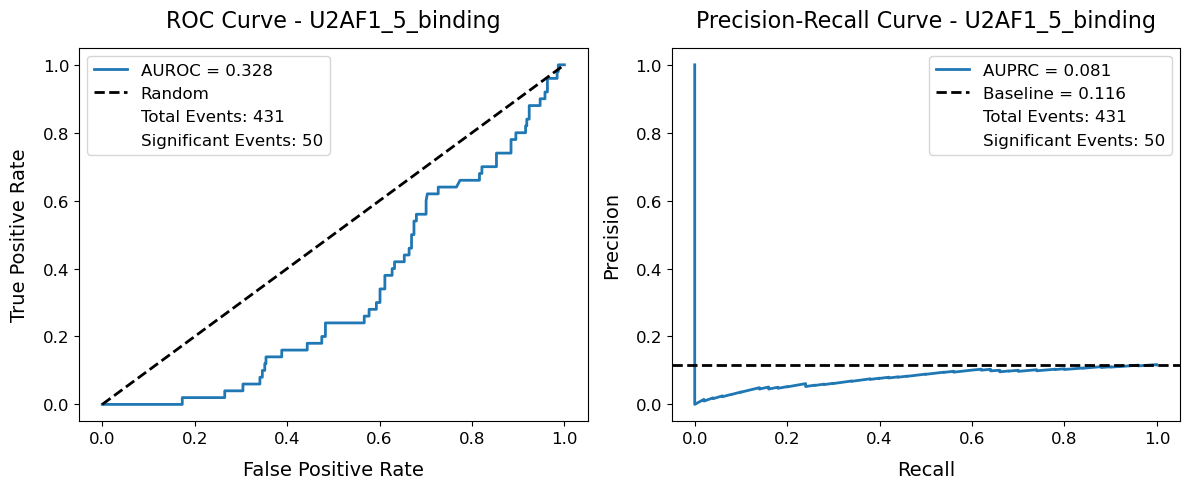

Plotting U2AF2_1_binding...


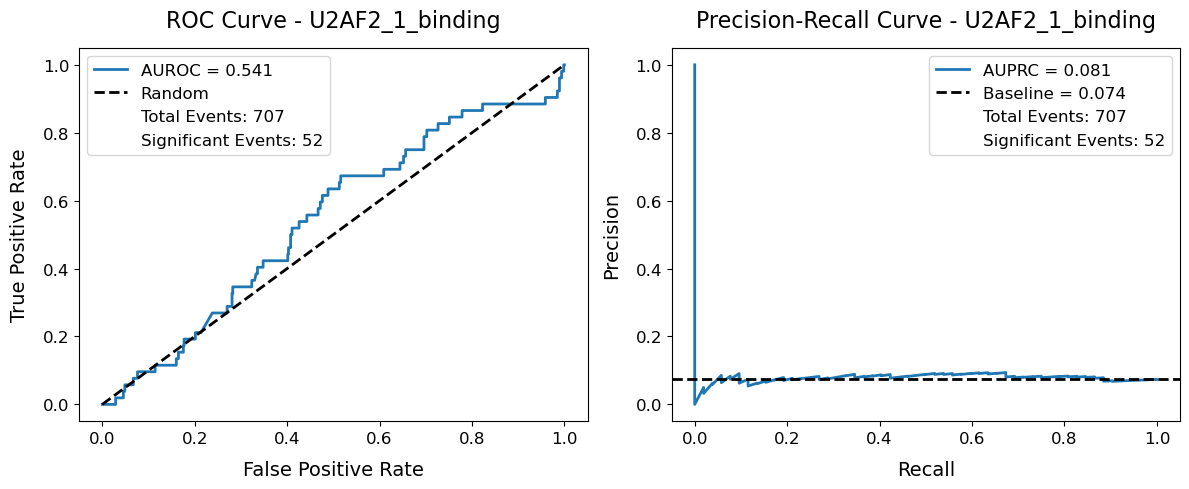

Plotting U2AF2_3_binding...


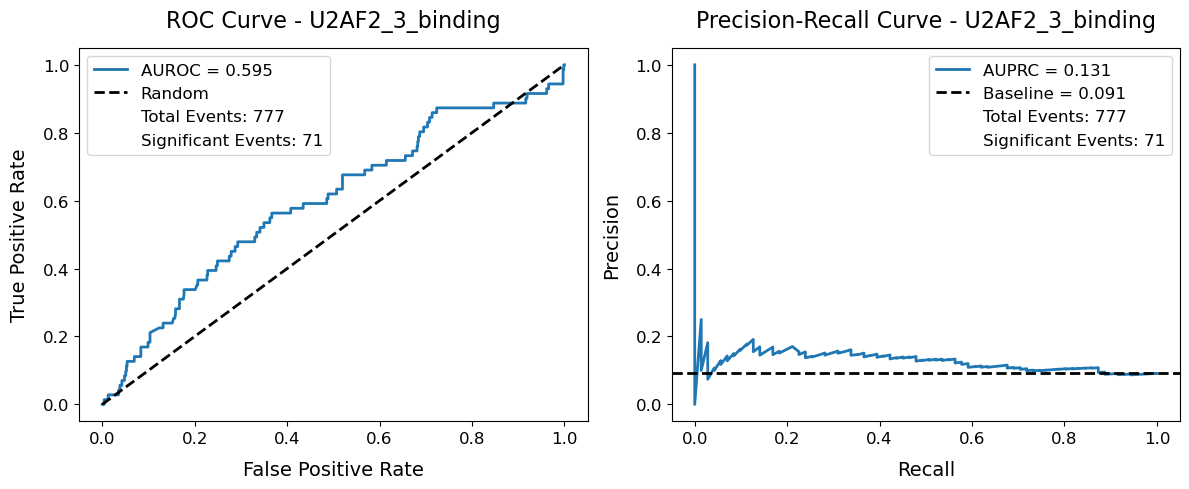

Plotting U2AF2_5_binding...


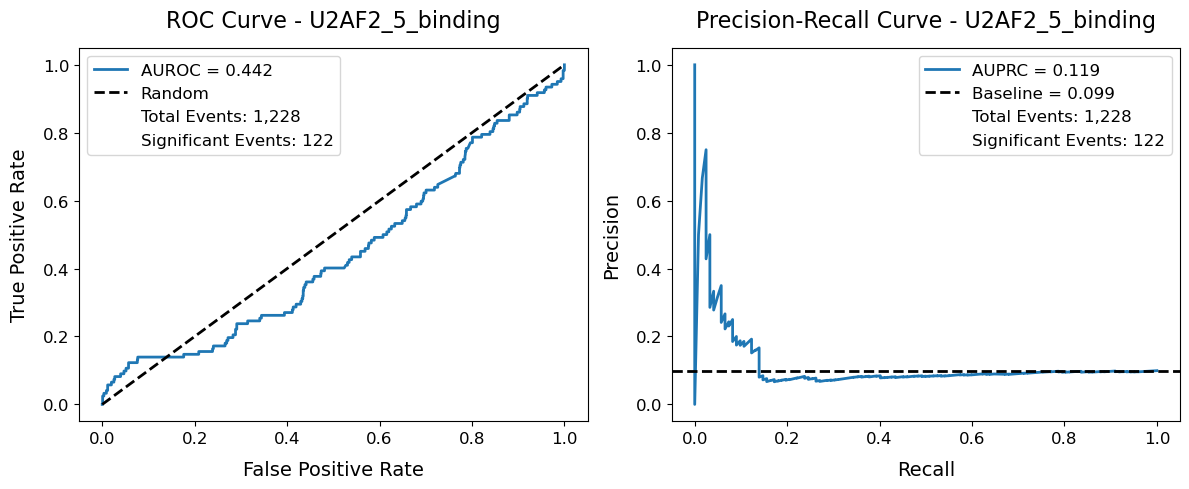


Final Results:
              Feature  AUROC  AUPRC  PRC Baseline  AUPRC - Baseline  \
0      AARS_1_binding    NaN    NaN           0.0               NaN   
1      AARS_2_binding    NaN    NaN           0.0               NaN   
2      AARS_3_binding    NaN    NaN           0.0               NaN   
3      AARS_5_binding    NaN    NaN           0.0               NaN   
4      AATF_1_binding    NaN    NaN           0.0               NaN   
..                ...    ...    ...           ...               ...   
542  ZRANB2_2_binding    NaN    NaN           0.0               NaN   
543  ZRANB2_3_binding    NaN    NaN           0.0               NaN   
544  ZRANB2_4_binding    NaN    NaN           0.0               NaN   
545  ZRANB2_5_binding    NaN    NaN           0.0               NaN   
546  ZRANB2_6_binding    NaN    NaN           0.0               NaN   

     Total Events  Num Significant  
0               2                0  
1               2                0  
2               4   

In [11]:
K562 = get_roc_prc("K562")

In [12]:
# Save and sort results
K562.to_csv('final_K562_ROC_PRC_results.csv', index = False)
HepG2.to_csv('final_HepG2_ROC_PRC_results.csv', index = False)

In [8]:
# Save and sort results
K562.to_csv('new_K562_ROC_PRC_results.csv', index = False)
HepG2.to_csv('new_HepG2_ROC_PRC_results.csv', index = False)

In [ ]:
# Top hits
print(K562[K562['Num Significant'] > 20].nlargest(10, 'AUROC'))

In [ ]:
print(K562[K562['Num Significant'] > 20].nlargest(10, 'AUPRC'))

In [ ]:
print(HepG2[HepG2['Num Significant'] > 20].nlargest(10, 'AUPRC'))

In [ ]:
print(HepG2[HepG2['Num Significant'] > 20].nlargest(10, 'AUROC'))

In [ ]:
# Add code that adds a column to the results dataframe with the AUPRC baseline value called "PRC Baseline" and a column that subtracts the baseline from the AUPRC